<a href="https://colab.research.google.com/github/diogo922/SSD/blob/main/SSD_Wine_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
# ==============================================================================
# 0. SETUP
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import (train_test_split, StratifiedKFold, cross_validate,
                                     RandomizedSearchCV, learning_curve)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             roc_auc_score, average_precision_score, roc_curve,
                             precision_recall_curve, f1_score, brier_score_loss)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 12, "axes.titleweight": "bold",
                     "figure.autolayout": False})
pd.set_option("display.width", 160, "display.max_columns", 40, "display.float_format", lambda v: f"{v:,.3f}")

print("Ambiente configurado.")


Ambiente configurado.


In [10]:
# ==============================================================================
# 0.1 CARGA DE DADOS (local -> fallback UCI)
# ==============================================================================
# Fontes tentadas em ordem: arquivo local (Colab: painel de arquivos) -> espelhos na web.
FONTES = [
    "winequality-red.csv",
    "/content/winequality-red.csv",
    "/mnt/user-data/uploads/winequality-red.csv",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv",
    "https://raw.githubusercontent.com/aniruddhachoudhury/Red-Wine-Quality/master/winequality-red.csv",
    "https://raw.githubusercontent.com/plotly/datasets/master/winequality-red.csv",
]

data = None
for fonte in FONTES:
    try:
        df_ = pd.read_csv(fonte, sep=None, engine="python", encoding="utf-8-sig")
        if df_.shape[1] >= 12 and "quality" in [c.strip().lower() for c in df_.columns]:
            data = df_
            print(f"Dados carregados de: {fonte}")
            break
    except Exception:
        continue

if data is None:
    raise FileNotFoundError(
        "Não foi possível carregar o dataset. No Colab, rode:\n"
        "  from google.colab import files; files.upload()\n"
        "e selecione o arquivo winequality-red.csv."
    )

# Padronização de nomes + dicionário de rótulos em PT para os gráficos
data.columns = [c.strip().lower().replace(" ", "_") for c in data.columns]

LABELS_PT = {
    "fixed_acidity": "Acidez fixa (g/L ác. tartárico)",
    "volatile_acidity": "Acidez volátil (g/L ác. acético)",
    "citric_acid": "Ácido cítrico (g/L)",
    "residual_sugar": "Açúcar residual (g/L)",
    "chlorides": "Cloretos (g/L NaCl)",
    "free_sulfur_dioxide": "SO2 livre (mg/L)",
    "total_sulfur_dioxide": "SO2 total (mg/L)",
    "density": "Densidade (g/cm³)",
    "ph": "pH",
    "sulphates": "Sulfatos (g/L K2SO4)",
    "alcohol": "Álcool (% vol.)",
    "quality": "Nota sensorial (0-10)",
}

# Alvo binário: nota >= 7 => premium (1)
LIMIAR_QUALIDADE = 7
data["premium"] = np.where(data["quality"] >= LIMIAR_QUALIDADE, 1, 0)

FEATURES = [c for c in data.columns if c not in ("quality", "premium")]
X_full = data[FEATURES].copy()
y_full = data["premium"].copy()

print(f"\nDimensões: {data.shape[0]} amostras x {len(FEATURES)} variáveis preditoras")
display(data.head())


Dados carregados de: https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv

Dimensões: 1599 amostras x 11 variáveis preditoras


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,premium
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,0
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5,0
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5,0
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6,0
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5,0


In [11]:
# ==============================================================================
# 1.1 PERFIL DO DATASET E QUALIDADE DOS DADOS
# ==============================================================================
perfil = pd.DataFrame({
    "tipo": data[FEATURES].dtypes.astype(str),
    "n_faltantes": data[FEATURES].isna().sum(),
    "n_zeros": (data[FEATURES] == 0).sum(),
    "n_unicos": data[FEATURES].nunique(),
    "media": data[FEATURES].mean(),
    "desvio": data[FEATURES].std(),
    "cv_%": (data[FEATURES].std() / data[FEATURES].mean() * 100),
    "assimetria": data[FEATURES].skew(),
    "curtose": data[FEATURES].kurtosis(),
})
perfil["cv_%"] = perfil["cv_%"].round(1)
print("PERFIL DAS VARIÁVEIS (ordenado por variabilidade relativa)")
display(perfil.sort_values("cv_%", ascending=False).round(3))

n_dup = data.duplicated().sum()
print(f"\n>>> Linhas duplicadas exatas: {n_dup} ({n_dup/len(data)*100:.1f}% da base)")
print(">>> ALERTA METODOLÓGICO: duplicatas divididas entre treino e teste geram vazamento")
print("    de dados (data leakage) e inflam artificialmente as métricas. Tratado no Módulo 4.")

print("\nDISTRIBUIÇÃO DO ALVO")
dist = data["quality"].value_counts().sort_index().rename("n").to_frame()
dist["%"] = (dist["n"] / len(data) * 100).round(1)
dist["classe"] = np.where(dist.index >= LIMIAR_QUALIDADE, "PREMIUM (1)", "COMUM (0)")
display(dist)
print(f"Taxa de premium: {y_full.mean()*100:.1f}%  ->  base desbalanceada (~1 para 6).")
print("Consequência: acurácia é métrica enganosa. Usaremos ROC-AUC, PR-AUC e lucro esperado.")


PERFIL DAS VARIÁVEIS (ordenado por variabilidade relativa)


,tipo,n_faltantes,n_zeros,n_unicos,media,desvio,cv_%,assimetria,curtose
citric_acid,float64,0,132,80,0.271,0.195,71.900,0.318,-0.789
total_sulfur_dioxide,float64,0,0,144,46.468,32.895,70.800,1.516,3.810
free_sulfur_dioxide,float64,0,0,60,15.875,10.460,65.900,1.251,2.024
residual_sugar,float64,0,0,91,2.539,1.410,55.500,4.541,28.618
chlorides,float64,0,0,153,0.087,0.047,53.800,5.680,41.716
volatile_acidity,float64,0,0,143,0.528,0.179,33.900,0.672,1.226
sulphates,float64,0,0,96,0.658,0.170,25.800,2.429,11.720
fixed_acidity,float64,0,0,96,8.320,1.741,20.900,0.983,1.132
alcohol,float64,0,0,65,10.423,1.066,10.200,0.861,0.200
ph,float64,0,0,89,3.311,0.154,4.700,0.194,0.807



>>> Linhas duplicadas exatas: 240 (15.0% da base)
>>> ALERTA METODOLÓGICO: duplicatas divididas entre treino e teste geram vazamento
    de dados (data leakage) e inflam artificialmente as métricas. Tratado no Módulo 4.

DISTRIBUIÇÃO DO ALVO


,n,%,classe
quality,,,
3,10,0.600,COMUM (0)
4,53,3.300,COMUM (0)
5,681,42.600,COMUM (0)
6,638,39.900,COMUM (0)
7,199,12.400,PREMIUM (1)
8,18,1.100,PREMIUM (1)


Taxa de premium: 13.6%  ->  base desbalanceada (~1 para 6).
Consequência: acurácia é métrica enganosa. Usaremos ROC-AUC, PR-AUC e lucro esperado.


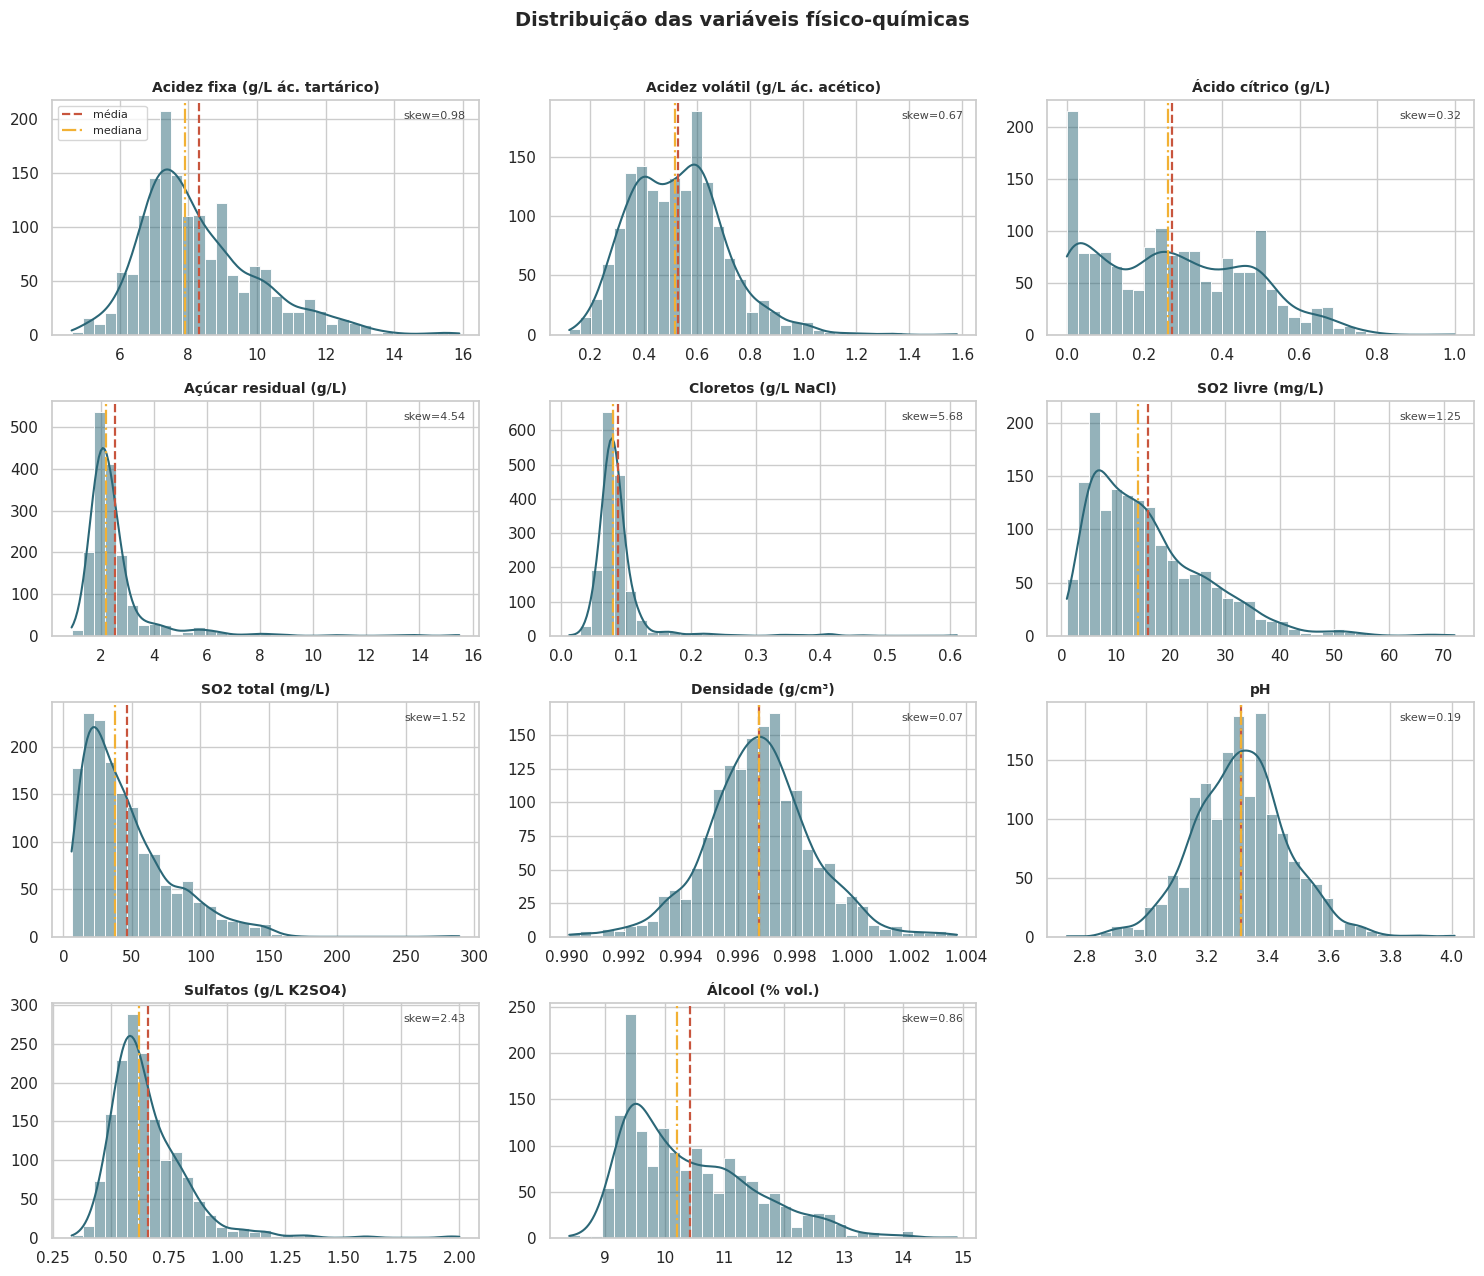

Leitura: cloretos, açúcar residual e sulfatos apresentam forte assimetria à direita —
cauda longa de valores extremos, típica de desvios pontuais de processo, não de ruído.


In [12]:

# ==============================================================================
# 1.2 DISTRIBUIÇÕES UNIVARIADAS
# ==============================================================================
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.histplot(data=data, x=col, bins=35, kde=True, ax=ax, color="#2b6777", edgecolor="white")
    ax.axvline(data[col].mean(), color="#c8553d", ls="--", lw=1.6, label="média")
    ax.axvline(data[col].median(), color="#f2b134", ls="-.", lw=1.6, label="mediana")
    ax.set_title(LABELS_PT.get(col, col), fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.text(0.97, 0.92, f"skew={data[col].skew():.2f}", transform=ax.transAxes,
            ha="right", fontsize=8, color="#444")
axes.ravel()[0].legend(fontsize=8)
axes.ravel()[-1].axis("off")
fig.suptitle("Distribuição das variáveis físico-químicas", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

print("Leitura: cloretos, açúcar residual e sulfatos apresentam forte assimetria à direita —")
print("cauda longa de valores extremos, típica de desvios pontuais de processo, não de ruído.")


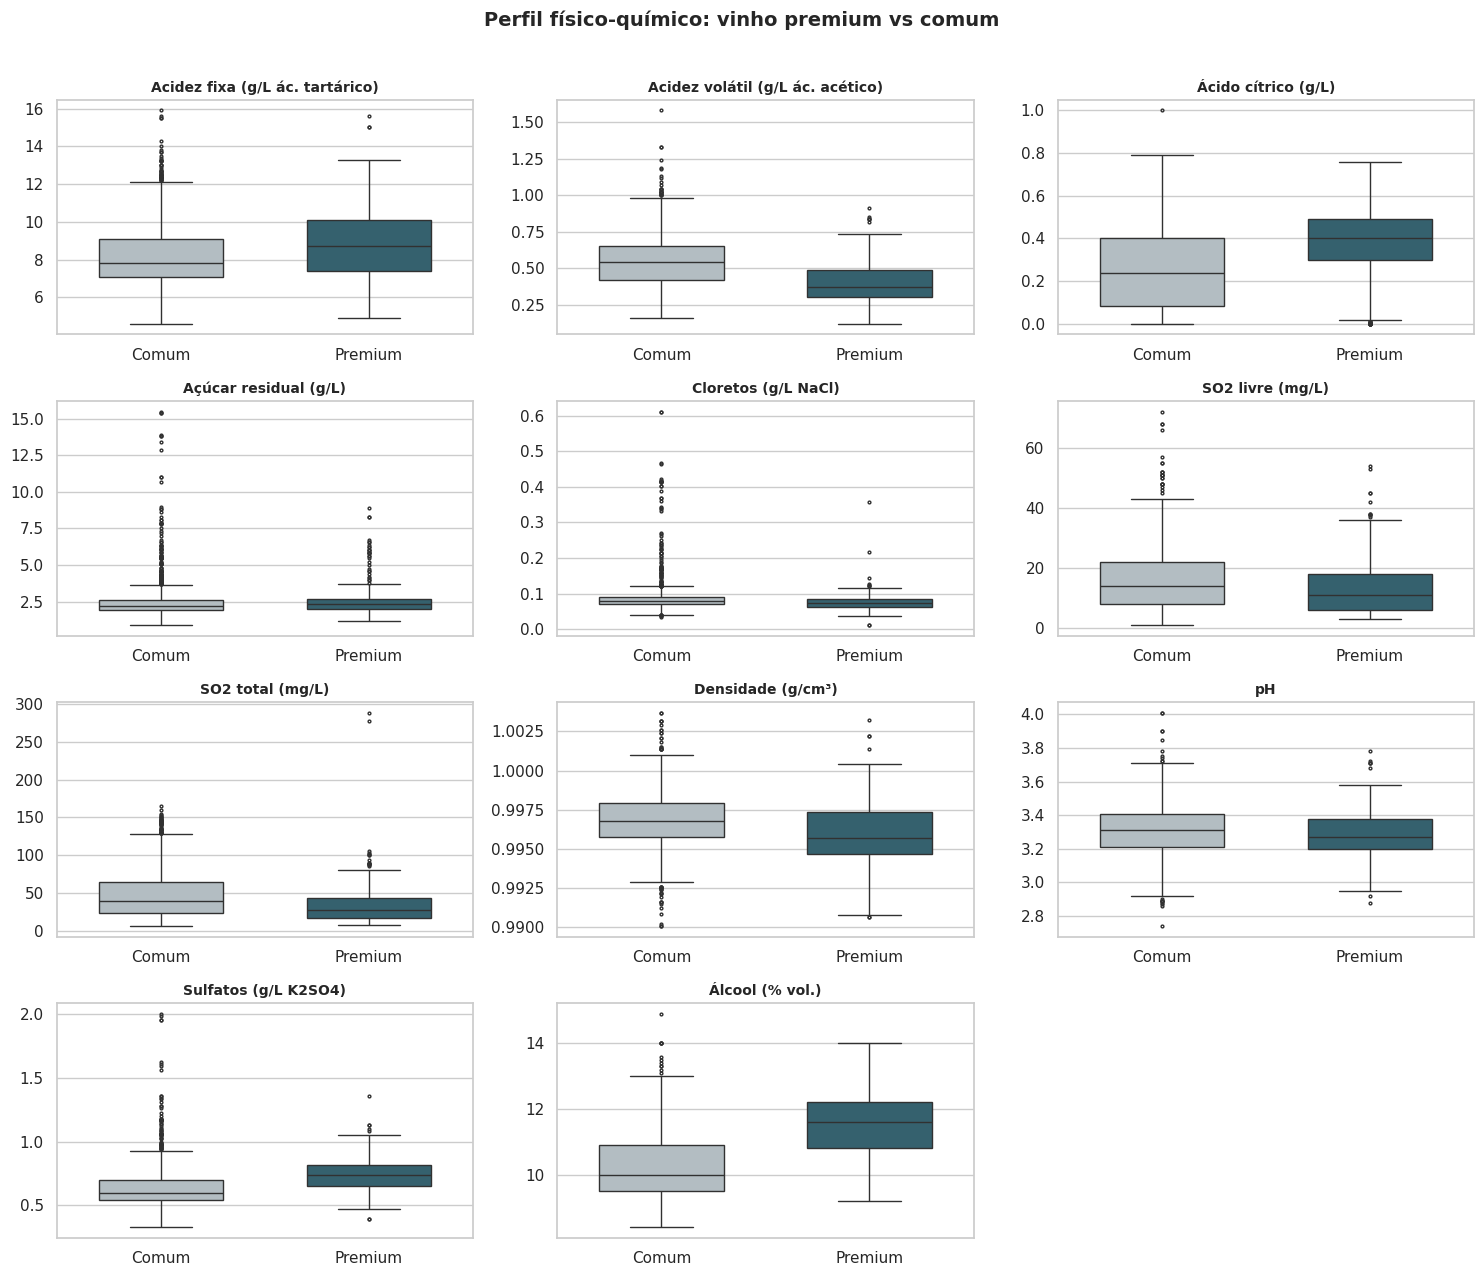

In [13]:
# ==============================================================================
# 1.3 COMPARAÇÃO PREMIUM vs COMUM (boxplots)
# ==============================================================================
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for ax, col in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=data, x="premium", y=col, hue="premium", ax=ax, legend=False,
                palette={0: "#b0bec5", 1: "#2b6777"}, width=0.6, fliersize=2)
    ax.set_title(LABELS_PT.get(col, col), fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Comum", "Premium"])
axes.ravel()[-1].axis("off")
fig.suptitle("Perfil físico-químico: vinho premium vs comum", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()




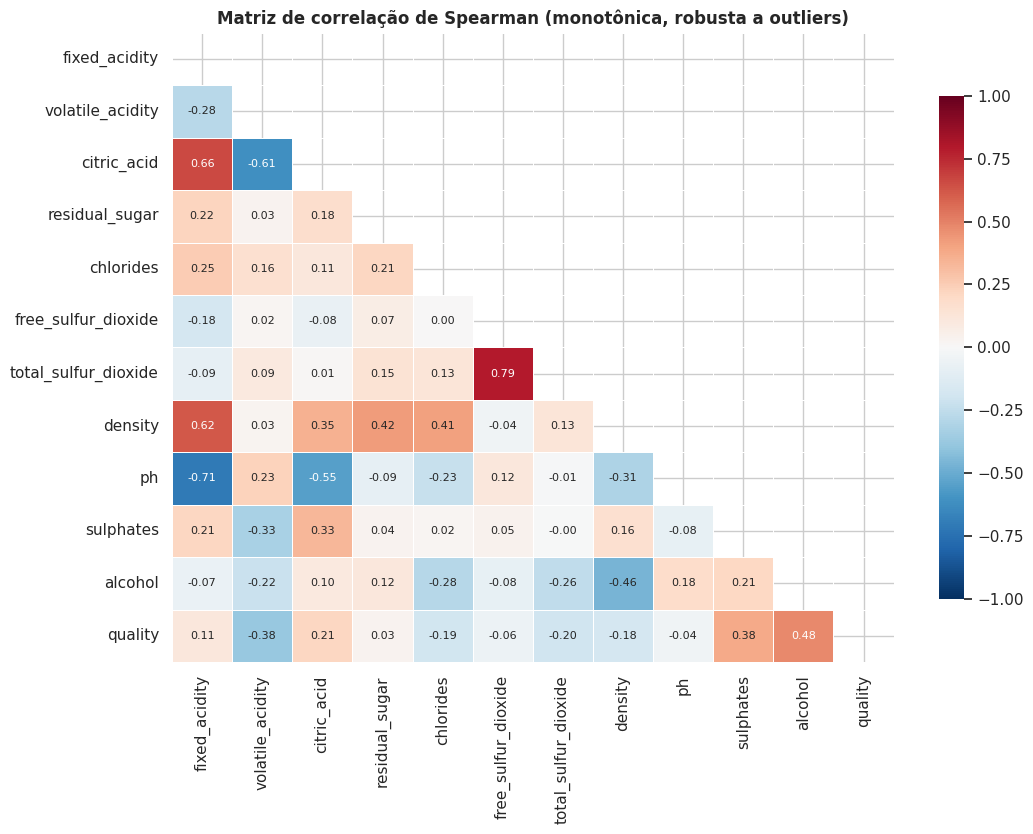

PARES COM MULTICOLINEARIDADE RELEVANTE (|rho| > 0,5):


,level_0,level_1,rho
20,total_sulfur_dioxide,free_sulfur_dioxide,0.790
28,ph,fixed_acidity,-0.707
1,citric_acid,fixed_acidity,0.662
21,density,fixed_acidity,0.623
2,citric_acid,volatile_acidity,-0.610
30,ph,citric_acid,-0.548


Implicação: acidez fixa / ácido cítrico / pH / densidade carregam informação redundante.
Modelos lineares terão coeficientes instáveis; modelos de árvore diluem a importância entre elas.


In [14]:
# ==============================================================================
# 1.4 MATRIZ DE CORRELAÇÃO
# ==============================================================================
corr = data[FEATURES + ["quality"]].corr(method="spearman")
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 8.5))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=False, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"size": 8})
ax.set_title("Matriz de correlação de Spearman (monotônica, robusta a outliers)")
plt.tight_layout()
plt.show()

alta_corr = (corr.where(~mask).stack().rename("rho").reset_index()
             .query("abs(rho) > 0.5 and level_0 != level_1")
             .sort_values("rho", key=abs, ascending=False))
print("PARES COM MULTICOLINEARIDADE RELEVANTE (|rho| > 0,5):")
display(alta_corr.round(3))
print("Implicação: acidez fixa / ácido cítrico / pH / densidade carregam informação redundante.")
print("Modelos lineares terão coeficientes instáveis; modelos de árvore diluem a importância entre elas.")



TESTE DE MANN-WHITNEY + TAMANHO DE EFEITO (ordenado por |d| de Cohen)


,variavel,media_premium,media_comum,delta_%,p_valor,cohen_d,efeito,p_bonferroni,significativo_5%
0,Álcool (% vol.),11.518,10.251,12.400,0.000,1.301,grande,0.000,True
1,Acidez volátil (g/L ác. acético),0.406,0.547,-25.900,0.000,-0.821,grande,0.000,True
2,Ácido cítrico (g/L),0.376,0.254,48.000,0.000,0.642,médio,0.000,True
3,Sulfatos (g/L K2SO4),0.743,0.645,15.300,0.000,0.594,médio,0.000,True
4,Densidade (g/cm³),0.996,0.997,-0.100,0.000,-0.444,pequeno,0.000,True
5,SO2 total (mg/L),34.889,48.286,-27.700,0.000,-0.411,pequeno,0.000,True
6,Acidez fixa (g/L ác. tartárico),8.847,8.237,7.400,0.000,0.353,pequeno,0.000,True
7,Cloretos (g/L NaCl),0.076,0.089,-15.000,0.000,-0.285,pequeno,0.000,True
8,SO2 livre (mg/L),13.982,16.172,-13.500,0.000,-0.210,pequeno,0.004,True
9,pH,3.289,3.315,-0.800,0.008,-0.167,desprezível,0.086,False


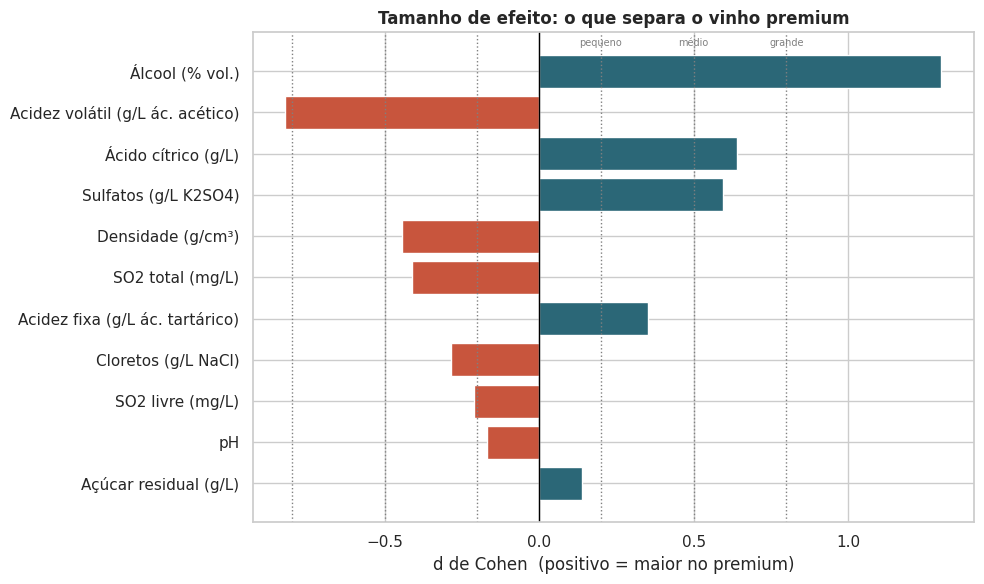

Conclusão diagnóstica: álcool é o único fator com efeito grande. Acidez volátil e sulfatos
têm efeito médio. Açúcar residual e pH não discriminam — candidatos a corte de escopo.


In [15]:
# ==============================================================================
# 2.1 TESTE DE HIPÓTESE + TAMANHO DE EFEITO
# ==============================================================================
# Correlação não mede relevância prática. Mann-Whitney testa se a diferença existe;
# o d de Cohen mede se ela importa.

def cohen_d(a, b):
    na, nb = len(a), len(b)
    s = np.sqrt(((na - 1) * a.var(ddof=1) + (nb - 1) * b.var(ddof=1)) / (na + nb - 2))
    return (a.mean() - b.mean()) / s if s > 0 else 0.0

def classificar_efeito(d):
    d = abs(d)
    return "desprezível" if d < 0.2 else "pequeno" if d < 0.5 else "médio" if d < 0.8 else "grande"

linhas = []
grupo_1 = data[data.premium == 1]
grupo_0 = data[data.premium == 0]
for col in FEATURES:
    a, b = grupo_1[col], grupo_0[col]
    u, p = stats.mannwhitneyu(a, b, alternative="two-sided")
    d = cohen_d(a, b)
    linhas.append({
        "variavel": LABELS_PT.get(col, col),
        "media_premium": a.mean(), "media_comum": b.mean(),
        "delta_%": (a.mean() - b.mean()) / b.mean() * 100,
        "p_valor": p, "cohen_d": d, "efeito": classificar_efeito(d),
    })

teste_df = pd.DataFrame(linhas).sort_values("cohen_d", key=abs, ascending=False).reset_index(drop=True)
# Correção de Bonferroni para múltiplas comparações
teste_df["p_bonferroni"] = np.minimum(teste_df["p_valor"] * len(FEATURES), 1.0)
teste_df["significativo_5%"] = teste_df["p_bonferroni"] < 0.05
print("TESTE DE MANN-WHITNEY + TAMANHO DE EFEITO (ordenado por |d| de Cohen)")
display(teste_df.round({"media_premium": 3, "media_comum": 3, "delta_%": 1,
                        "p_valor": 6, "p_bonferroni": 6, "cohen_d": 3}))

fig, ax = plt.subplots(figsize=(10, 6))
cores = ["#2b6777" if v > 0 else "#c8553d" for v in teste_df["cohen_d"]]
ax.barh(teste_df["variavel"], teste_df["cohen_d"], color=cores)
for lim, txt in [(0.2, "pequeno"), (0.5, "médio"), (0.8, "grande")]:
    ax.axvline(lim, color="grey", ls=":", lw=1); ax.axvline(-lim, color="grey", ls=":", lw=1)
    ax.text(lim, -0.6, txt, fontsize=7, ha="center", color="grey")
ax.axvline(0, color="black", lw=1)
ax.invert_yaxis()
ax.set_xlabel("d de Cohen  (positivo = maior no premium)")
ax.set_title("Tamanho de efeito: o que separa o vinho premium")
plt.tight_layout(); plt.show()

print("Conclusão diagnóstica: álcool é o único fator com efeito grande. Acidez volátil e sulfatos")
print("têm efeito médio. Açúcar residual e pH não discriminam — candidatos a corte de escopo.")


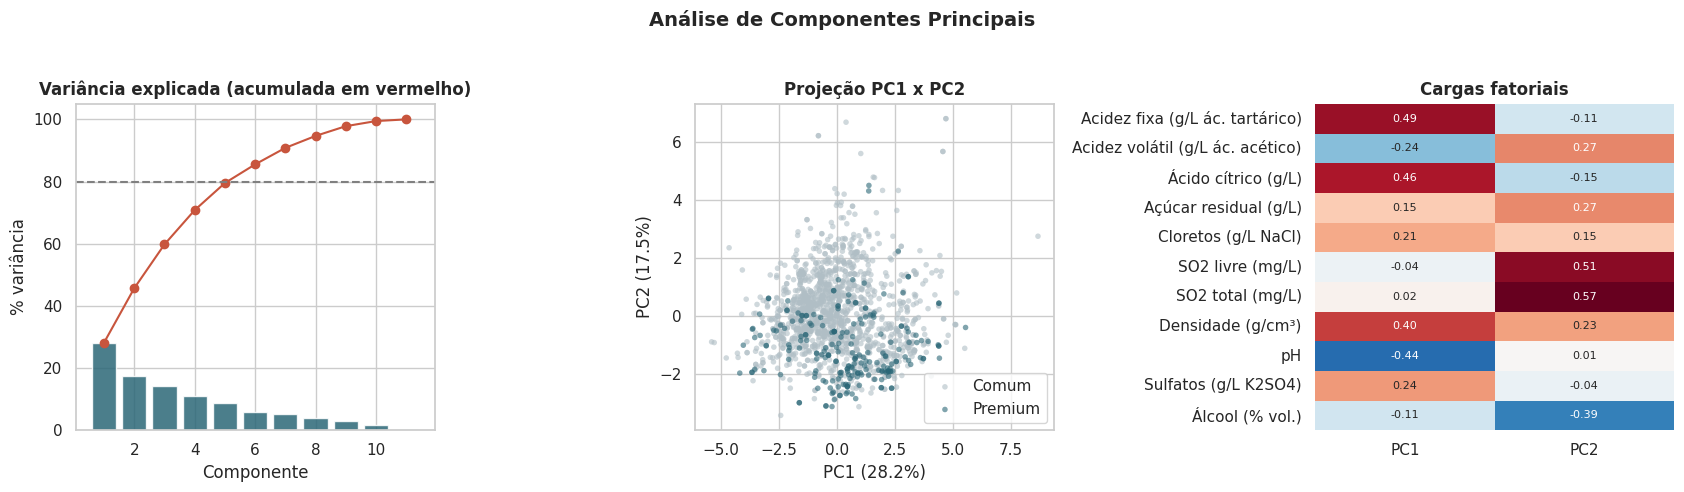

PC1+PC2 explicam apenas 45.7% da variância e as classes se sobrepõem
fortemente. Leitura de negócio: não existe fronteira linear simples — problema exige
modelo não-linear, e há teto realista de performance preditiva.


In [16]:
# ==============================================================================
# 2.2 PCA — ESTRUTURA LATENTE E SEPARABILIDADE
# ==============================================================================
X_pad = StandardScaler().fit_transform(X_full)
pca = PCA(n_components=len(FEATURES), random_state=RANDOM_STATE).fit(X_pad)
scores = pca.transform(X_pad)
var_exp = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].bar(range(1, len(var_exp) + 1), var_exp * 100, color="#2b6777", alpha=0.85)
axes[0].plot(range(1, len(var_exp) + 1), np.cumsum(var_exp) * 100, "o-", color="#c8553d")
axes[0].axhline(80, ls="--", color="grey")
axes[0].set_xlabel("Componente"); axes[0].set_ylabel("% variância")
axes[0].set_title("Variância explicada (acumulada em vermelho)")

for classe, cor, rot in [(0, "#b0bec5", "Comum"), (1, "#2b6777", "Premium")]:
    m = y_full == classe
    axes[1].scatter(scores[m, 0], scores[m, 1], s=16, alpha=0.6, c=cor, label=rot,
                    edgecolors="none")
axes[1].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)"); axes[1].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[1].legend(); axes[1].set_title("Projeção PC1 x PC2")

carga = pd.DataFrame(pca.components_[:2].T, index=[LABELS_PT.get(c, c) for c in FEATURES],
                     columns=["PC1", "PC2"])
sns.heatmap(carga, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[2],
            cbar=False, annot_kws={"size": 8})
axes[2].set_title("Cargas fatoriais")
fig.suptitle("Análise de Componentes Principais", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

print(f"PC1+PC2 explicam apenas {var_exp[:2].sum()*100:.1f}% da variância e as classes se sobrepõem")
print("fortemente. Leitura de negócio: não existe fronteira linear simples — problema exige")
print("modelo não-linear, e há teto realista de performance preditiva.")

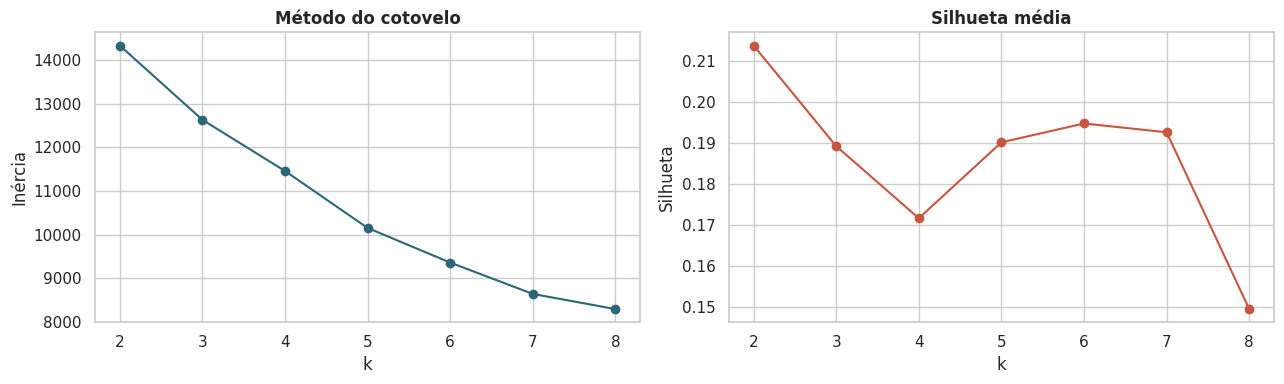

PERFIL MÉDIO DOS 4 SEGMENTOS


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,n,taxa_premium_%
cluster,,,,,,,,,,,,,,
0,7.505,0.650,0.115,2.239,0.084,11.737,34.250,0.997,3.371,0.589,9.949,5.333,553,4.000
1,7.120,0.447,0.242,2.169,0.067,17.568,39.586,0.994,3.409,0.680,11.742,6.140,314,29.300
2,10.472,0.414,0.490,2.650,0.107,10.503,30.990,0.998,3.173,0.760,10.537,5.902,398,22.400
3,8.231,0.537,0.296,3.250,0.089,27.536,91.611,0.997,3.284,0.630,9.831,5.347,334,4.200


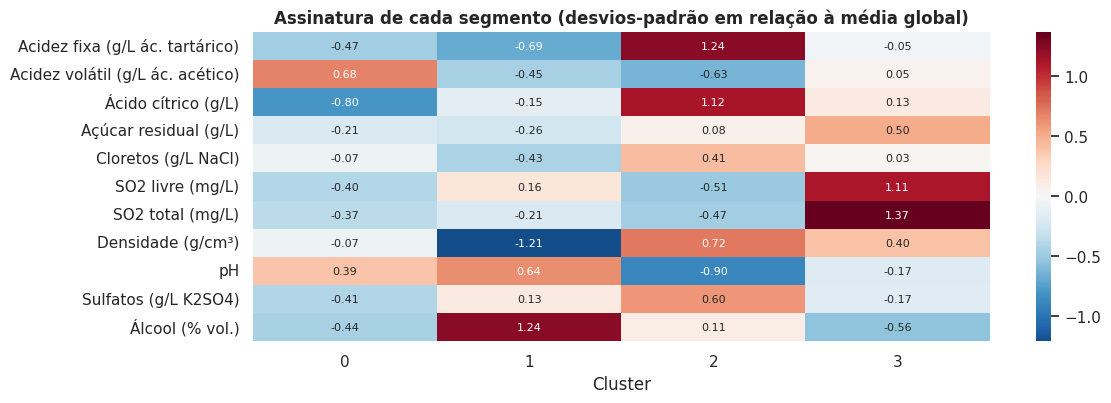

Cluster 1 concentra a maior taxa de premium (29.3%)
Cluster 0 é o de pior desempenho (4.0%).
Uso prático: rotular lotes por segmento no LIMS permite roteirizar a produção antes do painel sensorial.


In [17]:
# ==============================================================================
# 2.3 SEGMENTAÇÃO DE PERFIS ENOLÓGICOS (K-MEANS)
# ==============================================================================
inercia, silhuetas = [], []
from sklearn.metrics import silhouette_score
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_pad)
    inercia.append(km.inertia_)
    silhuetas.append(silhouette_score(X_pad, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(range(2, 9), inercia, "o-", color="#2b6777"); axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia")
axes[1].plot(range(2, 9), silhuetas, "o-", color="#c8553d"); axes[1].set_title("Silhueta média")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhueta")
plt.tight_layout(); plt.show()

K = 4
km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_pad)
data["cluster"] = km.labels_

perfil_cluster = data.groupby("cluster")[FEATURES + ["quality", "premium"]].mean()
perfil_cluster["n"] = data.groupby("cluster").size()
perfil_cluster["taxa_premium_%"] = (perfil_cluster["premium"] * 100).round(1)
print(f"PERFIL MÉDIO DOS {K} SEGMENTOS")
display(perfil_cluster.drop(columns="premium").round(3))

# Heatmap de desvio padronizado por cluster (z-score em relação à média global)
z = (perfil_cluster[FEATURES] - data[FEATURES].mean()) / data[FEATURES].std()
fig, ax = plt.subplots(figsize=(12, 4.2))
sns.heatmap(z.T, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            yticklabels=[LABELS_PT.get(c, c) for c in FEATURES], annot_kws={"size": 8})
ax.set_title("Assinatura de cada segmento (desvios-padrão em relação à média global)")
ax.set_xlabel("Cluster")
plt.tight_layout(); plt.show()

melhor = perfil_cluster["taxa_premium_%"].idxmax()
pior = perfil_cluster["taxa_premium_%"].idxmin()
print(f"Cluster {melhor} concentra a maior taxa de premium ({perfil_cluster.loc[melhor,'taxa_premium_%']}%)")
print(f"Cluster {pior} é o de pior desempenho ({perfil_cluster.loc[pior,'taxa_premium_%']}%).")
print("Uso prático: rotular lotes por segmento no LIMS permite roteirizar a produção antes do painel sensorial.")



In [18]:
# ==============================================================================
# 3.1 INFRAESTRUTURA DE CEP: CONSTANTES E REGRAS DE NELSON
# ==============================================================================
# Constantes de cartas de controle (Montgomery, Introduction to SQC)
CONSTANTES = pd.DataFrame({
    "n":  [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "A2": [1.880, 1.023, 0.729, 0.577, 0.483, 0.419, 0.373, 0.337, 0.308],
    "d2": [1.128, 1.693, 2.059, 2.326, 2.534, 2.704, 2.847, 2.970, 3.078],
    "D3": [0, 0, 0, 0, 0, 0.076, 0.136, 0.184, 0.223],
    "D4": [3.267, 2.574, 2.282, 2.114, 2.004, 1.924, 1.864, 1.816, 1.777],
}).set_index("n")

def regras_nelson(serie, lc, sigma):
    """Retorna dict {regra: índices violados}. Implementa as 5 regras mais usadas."""
    s = np.asarray(serie, dtype=float)
    n = len(s)
    v = {}
    # R1: 1 ponto além de 3 sigma
    v["R1: ponto fora de 3σ (causa especial)"] = np.where(np.abs(s - lc) > 3 * sigma)[0].astype(int)
    # R2: 9 pontos consecutivos do mesmo lado da linha central
    lado = np.sign(s - lc)
    idx = []
    for i in range(n - 8):
        j = lado[i:i + 9]
        if np.all(j > 0) or np.all(j < 0):
            idx.append(i + 8)
    v["R2: 9 pontos do mesmo lado (deslocamento)"] = np.array(idx, dtype=int)
    # R3: 6 pontos consecutivos crescentes ou decrescentes
    d = np.diff(s)
    idx = [i + 6 for i in range(n - 6) if np.all(d[i:i + 6] > 0) or np.all(d[i:i + 6] < 0)]
    v["R3: 6 pontos em tendência (deriva)"] = np.array(idx, dtype=int)
    # R5: 2 de 3 pontos além de 2 sigma (mesmo lado)
    idx = []
    for i in range(n - 2):
        jan = s[i:i + 3]
        if (np.sum(jan > lc + 2 * sigma) >= 2) or (np.sum(jan < lc - 2 * sigma) >= 2):
            idx.append(i + 2)
    v["R5: 2 de 3 além de 2σ (alerta)"] = np.array(idx, dtype=int)
    # R6: 4 de 5 pontos além de 1 sigma (mesmo lado)
    idx = []
    for i in range(n - 4):
        jan = s[i:i + 5]
        if (np.sum(jan > lc + sigma) >= 4) or (np.sum(jan < lc - sigma) >= 4):
            idx.append(i + 4)
    v["R6: 4 de 5 além de 1σ (alerta)"] = np.array(idx, dtype=int)
    return v

def plot_carta(ax, valores, lc, lsc, lic, titulo, ylabel, sigma=None, marcar=None):
    ax.plot(valores, "o-", ms=3.2, lw=0.9, color="#2b6777", zorder=2)
    ax.axhline(lc, color="#1b5e20", lw=1.4, label=f"LC = {lc:.4g}")
    ax.axhline(lsc, color="#c8553d", ls="--", lw=1.4, label=f"LSC = {lsc:.4g}")
    ax.axhline(lic, color="#c8553d", ls="--", lw=1.4, label=f"LIC = {lic:.4g}")
    if sigma is not None:
        for k, alpha in [(1, 0.06), (2, 0.06)]:
            ax.axhspan(lc + (k - 1) * sigma, lc + k * sigma, color="grey", alpha=alpha, zorder=0)
            ax.axhspan(lc - k * sigma, lc - (k - 1) * sigma, color="grey", alpha=alpha, zorder=0)
    fora = np.where((np.asarray(valores) > lsc) | (np.asarray(valores) < lic))[0]
    if len(fora):
        ax.scatter(fora, np.asarray(valores)[fora], color="red", s=45, zorder=3,
                   label=f"{len(fora)} fora de controle")
    if marcar is not None and len(marcar):
        marcar = np.asarray(marcar, dtype=int)
        ax.scatter(marcar, np.asarray(valores)[marcar], facecolors="none", edgecolors="#f2b134",
                   s=90, lw=1.6, zorder=3, label="alerta (regras 2/3/5/6)")
    ax.set_title(titulo); ax.set_ylabel(ylabel); ax.set_xlabel("Sequência de amostragem")
    ax.legend(fontsize=7, ncol=2, loc="upper right")

print("Funções de CEP definidas: regras de Nelson (R1, R2, R3, R5, R6) e plotagem padronizada.")


Funções de CEP definidas: regras de Nelson (R1, R2, R3, R5, R6) e plotagem padronizada.


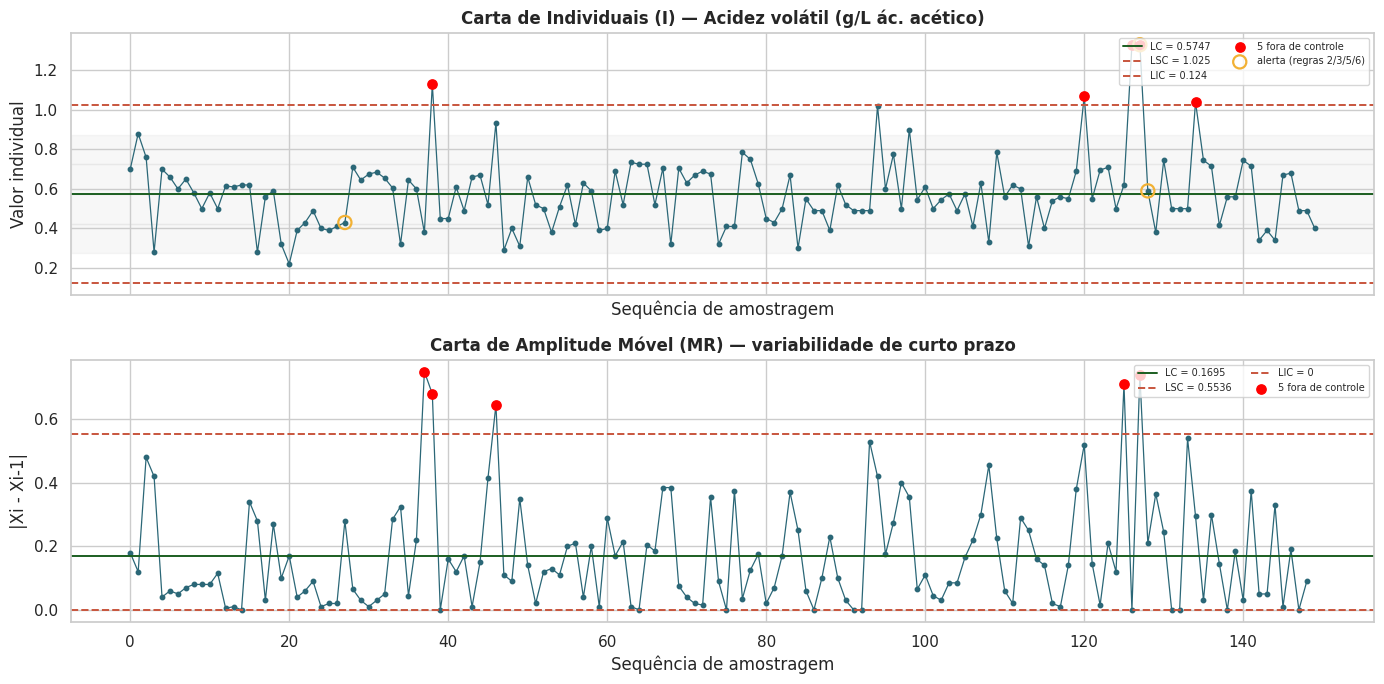

--- DIAGNÓSTICO CEP: Acidez volátil (g/L ác. acético) ---
Linha central = 0.5747 | sigma (MR/d2) = 0.1502 | LSC = 1.0254 | LIC = 0.1240
  [ALERTA] R1: ponto fora de 3σ (causa especial): 5 ocorrência(s) -> amostras [np.int64(38), np.int64(120), np.int64(126), np.int64(127), np.int64(134)]
  [ALERTA] R2: 9 pontos do mesmo lado (deslocamento): 1 ocorrência(s) -> amostras [np.int64(27)]
  [ok] R3: 6 pontos em tendência (deriva): 0 ocorrência(s)
  [ALERTA] R5: 2 de 3 além de 2σ (alerta): 2 ocorrência(s) -> amostras [np.int64(127), np.int64(128)]
  [ok] R6: 4 de 5 além de 1σ (alerta): 0 ocorrência(s)



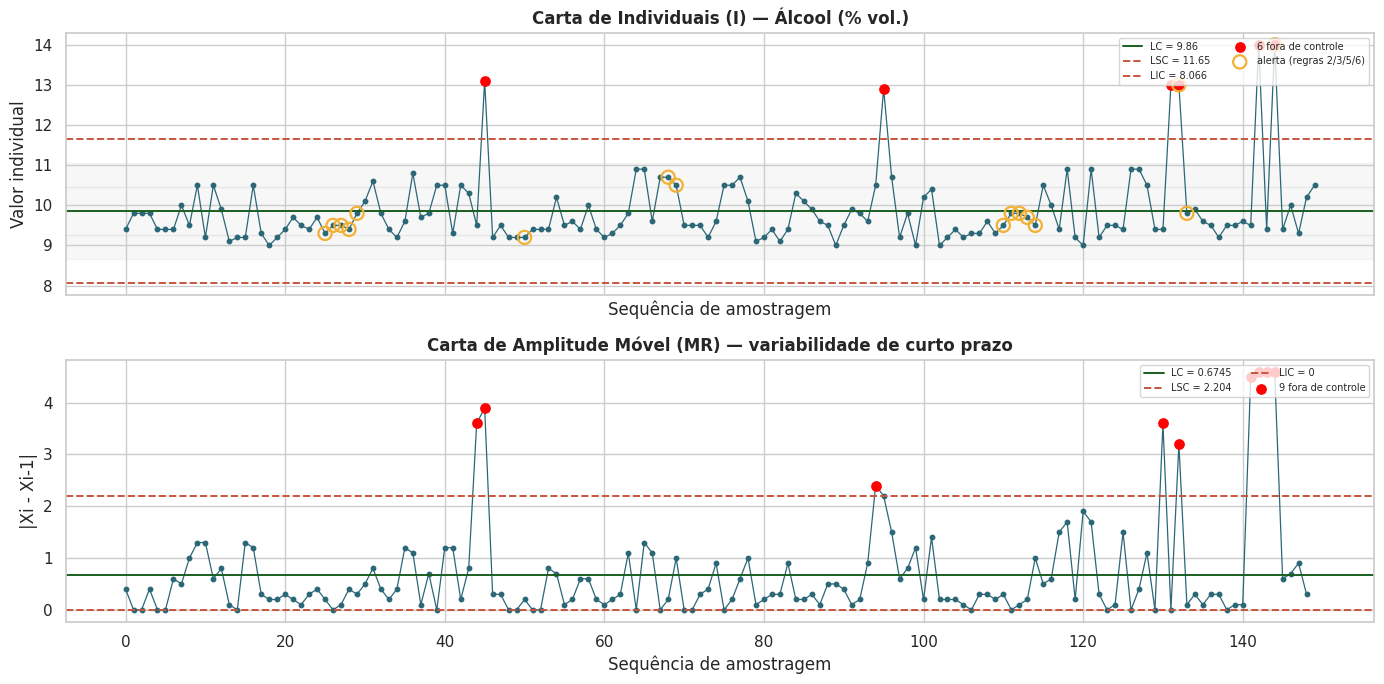

--- DIAGNÓSTICO CEP: Álcool (% vol.) ---
Linha central = 9.8600 | sigma (MR/d2) = 0.5980 | LSC = 11.6539 | LIC = 8.0661
  [ALERTA] R1: ponto fora de 3σ (causa especial): 6 ocorrência(s) -> amostras [np.int64(45), np.int64(95), np.int64(131), np.int64(132), np.int64(142), np.int64(144)]
  [ALERTA] R2: 9 pontos do mesmo lado (deslocamento): 10 ocorrência(s) -> amostras [np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(110), np.int64(111), np.int64(112)]...
  [ok] R3: 6 pontos em tendência (deriva): 0 ocorrência(s)
  [ALERTA] R5: 2 de 3 além de 2σ (alerta): 3 ocorrência(s) -> amostras [np.int64(132), np.int64(133), np.int64(144)]
  [ALERTA] R6: 4 de 5 além de 1σ (alerta): 3 ocorrência(s) -> amostras [np.int64(50), np.int64(68), np.int64(69)]



In [19]:
# ==============================================================================
# 3.2 CARTA DE INDIVIDUAIS E AMPLITUDE MÓVEL (I-MR)
# ==============================================================================
# Variável crítica de qualidade: acidez volátil (defeito de avinagramento) e álcool.
JANELA = 150  # primeiras 150 amostras, para leitura visual
d2_2 = CONSTANTES.loc[2, "d2"]
D4_2 = CONSTANTES.loc[2, "D4"]

for var in ["volatile_acidity", "alcohol"]:
    x = data[var].iloc[:JANELA].to_numpy()
    mr = np.abs(np.diff(x))
    mr_bar = mr.mean()
    lc_i = x.mean()
    sigma_i = mr_bar / d2_2          # estimativa robusta de sigma (variabilidade de curto prazo)
    lsc_i, lic_i = lc_i + 3 * sigma_i, lc_i - 3 * sigma_i

    viol = regras_nelson(x, lc_i, sigma_i)
    alertas = np.unique(np.concatenate([v for k, v in viol.items() if not k.startswith("R1")] + [np.array([], dtype=int)]))

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    plot_carta(axes[0], x, lc_i, lsc_i, lic_i,
               f"Carta de Individuais (I) — {LABELS_PT[var]}", "Valor individual",
               sigma=sigma_i, marcar=alertas)
    plot_carta(axes[1], mr, mr_bar, D4_2 * mr_bar, 0.0,
               "Carta de Amplitude Móvel (MR) — variabilidade de curto prazo", "|Xi - Xi-1|")
    plt.tight_layout(); plt.show()

    print(f"--- DIAGNÓSTICO CEP: {LABELS_PT[var]} ---")
    print(f"Linha central = {lc_i:.4f} | sigma (MR/d2) = {sigma_i:.4f} | LSC = {lsc_i:.4f} | LIC = {lic_i:.4f}")
    for regra, idxs in viol.items():
        marca = "ALERTA" if len(idxs) else "ok"
        print(f"  [{marca}] {regra}: {len(idxs)} ocorrência(s)"
              + (f" -> amostras {list(idxs[:8])}{'...' if len(idxs) > 8 else ''}" if len(idxs) else ""))
    print()


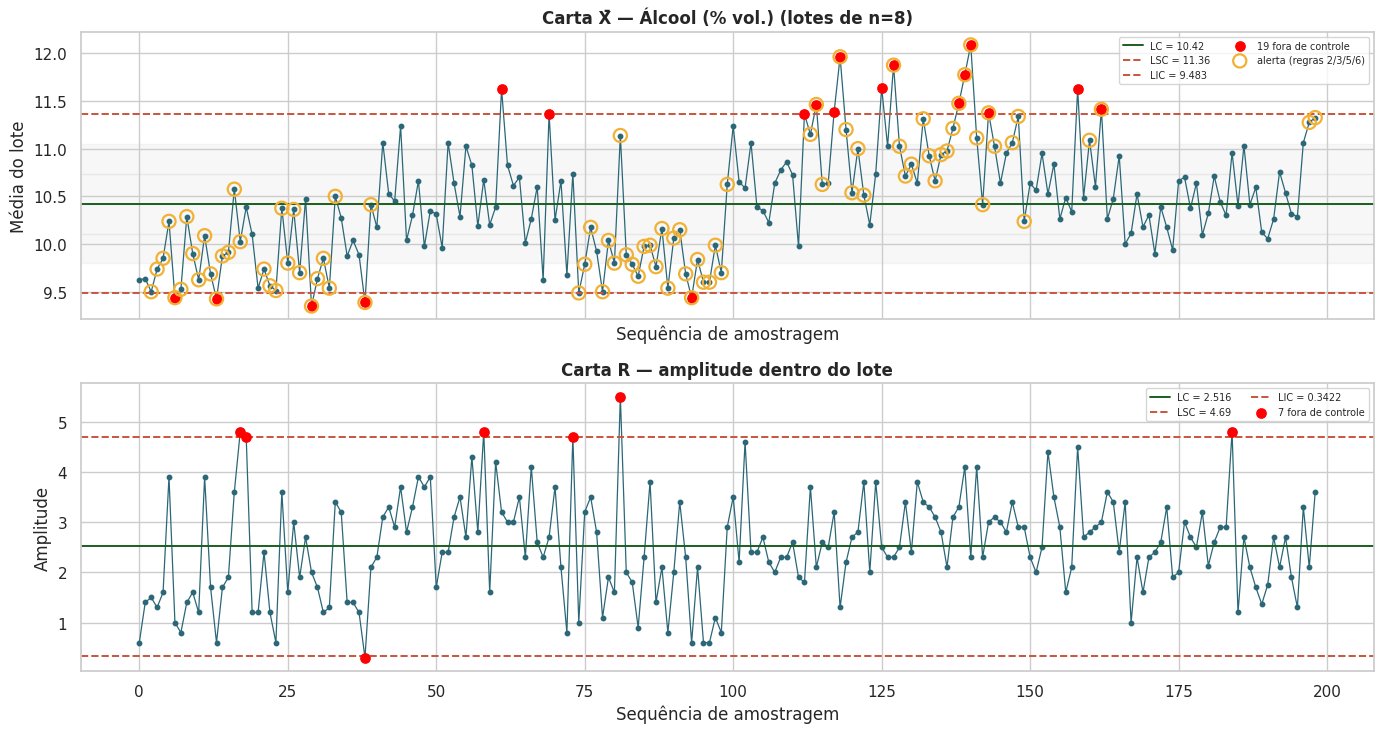

Lotes analisados: 199 | X̄̄ = 10.422 | R̄ = 2.516 | sigma(dentro) = 0.884
Pontos fora de controle -> Carta X̄: 19 (9.5%) | Carta R: 7 (3.5%)

Interpretação: em um processo estável esperaríamos ~0,27% de falsos alarmes (3σ).
Percentuais muito acima disso indicam causas especiais recorrentes — o 'processo' de
origem dos vinhos mistura safras/produtores distintos, o que é exatamente o tipo de
heterogeneidade que degrada modelos preditivos em produção (drift estrutural).


In [20]:
# ==============================================================================
# 3.3 CARTA X-BARRA / R  (SUBGRUPOS RACIONAIS = LOTES DE PRODUÇÃO)
# ==============================================================================
TAM_LOTE = 8
A2, D3, D4, d2 = CONSTANTES.loc[TAM_LOTE, ["A2", "D3", "D4", "d2"]]

var_cep = "alcohol"
n_lotes = len(data) // TAM_LOTE
mat = data[var_cep].iloc[:n_lotes * TAM_LOTE].to_numpy().reshape(n_lotes, TAM_LOTE)

xbar = mat.mean(axis=1)
r = mat.max(axis=1) - mat.min(axis=1)
xbarbar, rbar = xbar.mean(), r.mean()
sigma_dentro = rbar / d2

lsc_x, lic_x = xbarbar + A2 * rbar, xbarbar - A2 * rbar
lsc_r, lic_r = D4 * rbar, D3 * rbar

viol_x = regras_nelson(xbar, xbarbar, A2 * rbar / 3)
alertas_x = np.unique(np.concatenate([v for k, v in viol_x.items() if not k.startswith("R1")] + [np.array([], dtype=int)]))

fig, axes = plt.subplots(2, 1, figsize=(14, 7.5), sharex=True)
plot_carta(axes[0], xbar, xbarbar, lsc_x, lic_x,
           f"Carta X̄ — {LABELS_PT[var_cep]} (lotes de n={TAM_LOTE})", "Média do lote",
           sigma=A2 * rbar / 3, marcar=alertas_x)
plot_carta(axes[1], r, rbar, lsc_r, lic_r, "Carta R — amplitude dentro do lote", "Amplitude")
plt.tight_layout(); plt.show()

fora_x = int(((xbar > lsc_x) | (xbar < lic_x)).sum())
fora_r = int(((r > lsc_r) | (r < lic_r)).sum())
print(f"Lotes analisados: {n_lotes} | X̄̄ = {xbarbar:.3f} | R̄ = {rbar:.3f} | sigma(dentro) = {sigma_dentro:.3f}")
print(f"Pontos fora de controle -> Carta X̄: {fora_x} ({fora_x/n_lotes*100:.1f}%) | Carta R: {fora_r} ({fora_r/n_lotes*100:.1f}%)")
print("\nInterpretação: em um processo estável esperaríamos ~0,27% de falsos alarmes (3σ).")
print("Percentuais muito acima disso indicam causas especiais recorrentes — o 'processo' de")
print("origem dos vinhos mistura safras/produtores distintos, o que é exatamente o tipo de")
print("heterogeneidade que degrada modelos preditivos em produção (drift estrutural).")



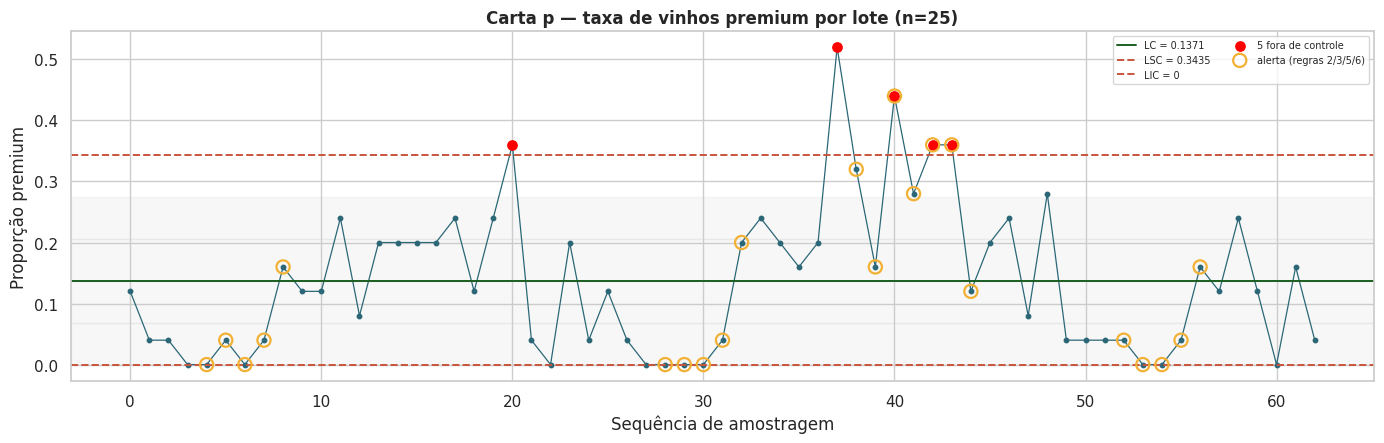

p̄ = 0.137 (13.7% de aprovação premium) | LSC = 0.344 | LIC = 0.000
Lotes fora de controle: 5 -> [20, 37, 40, 42, 43]

Uso gerencial: esta é a carta que vai para a reunião de produção. Cada ponto acima do LSC
é um lote a ser investigado como *boa prática replicável*; abaixo do LIC, investigação de falha.


In [21]:
# ==============================================================================
# 3.4 CARTA p — PROPORÇÃO DE APROVAÇÃO PREMIUM POR LOTE (ATRIBUTO)
# ==============================================================================
TAM_LOTE_P = 25
n_lotes_p = len(data) // TAM_LOTE_P
prem = data["premium"].iloc[:n_lotes_p * TAM_LOTE_P].to_numpy().reshape(n_lotes_p, TAM_LOTE_P)
p_i = prem.mean(axis=1)
p_bar = p_i.mean()
sigma_p = np.sqrt(p_bar * (1 - p_bar) / TAM_LOTE_P)
lsc_p, lic_p = p_bar + 3 * sigma_p, max(0, p_bar - 3 * sigma_p)

viol_p = regras_nelson(p_i, p_bar, sigma_p)
alertas_p = np.unique(np.concatenate([v for k, v in viol_p.items() if not k.startswith("R1")] + [np.array([], dtype=int)]))

fig, ax = plt.subplots(figsize=(14, 4.6))
plot_carta(ax, p_i, p_bar, lsc_p, lic_p,
           f"Carta p — taxa de vinhos premium por lote (n={TAM_LOTE_P})",
           "Proporção premium", sigma=sigma_p, marcar=alertas_p)
plt.tight_layout(); plt.show()

print(f"p̄ = {p_bar:.3f} ({p_bar*100:.1f}% de aprovação premium) | LSC = {lsc_p:.3f} | LIC = {lic_p:.3f}")
fora_p = np.where((p_i > lsc_p) | (p_i < lic_p))[0]
print(f"Lotes fora de controle: {len(fora_p)} -> {[int(i) for i in fora_p]}")
print("\nUso gerencial: esta é a carta que vai para a reunião de produção. Cada ponto acima do LSC")
print("é um lote a ser investigado como *boa prática replicável*; abaixo do LIC, investigação de falha.")


ANÁLISE DE CAPACIDADE — Cpk < 1,00 = processo incapaz | 1,33 = mínimo aceitável | 1,67 = classe mundial


,LIE,LSE,media,sigma_dentro,sigma_total,Cp,Cpk,Pp,Ppk,ppm_observado,veredito
variavel,,,,,,,,,,,
Acidez volátil (g/L ác. acético),NaN,0.600,0.528,0.158,0.179,NaN,0.152,NaN,0.134,"315,196.998",INCAPAZ (ação imediata)
Álcool (% vol.),10.500,NaN,10.423,0.884,1.066,NaN,-0.029,NaN,-0.024,"572,858.036",INCAPAZ (ação imediata)
SO2 total (mg/L),NaN,100.000,46.468,27.668,32.895,NaN,0.645,NaN,0.542,"79,424.640",INCAPAZ (ação imediata)
pH,3.100,3.550,3.311,0.136,0.154,0.553,0.519,0.486,0.456,"130,706.692",INCAPAZ (ação imediata)
Sulfatos (g/L K2SO4),0.550,1.000,0.658,0.133,0.170,0.562,0.270,0.442,0.213,"267,667.292",INCAPAZ (ação imediata)


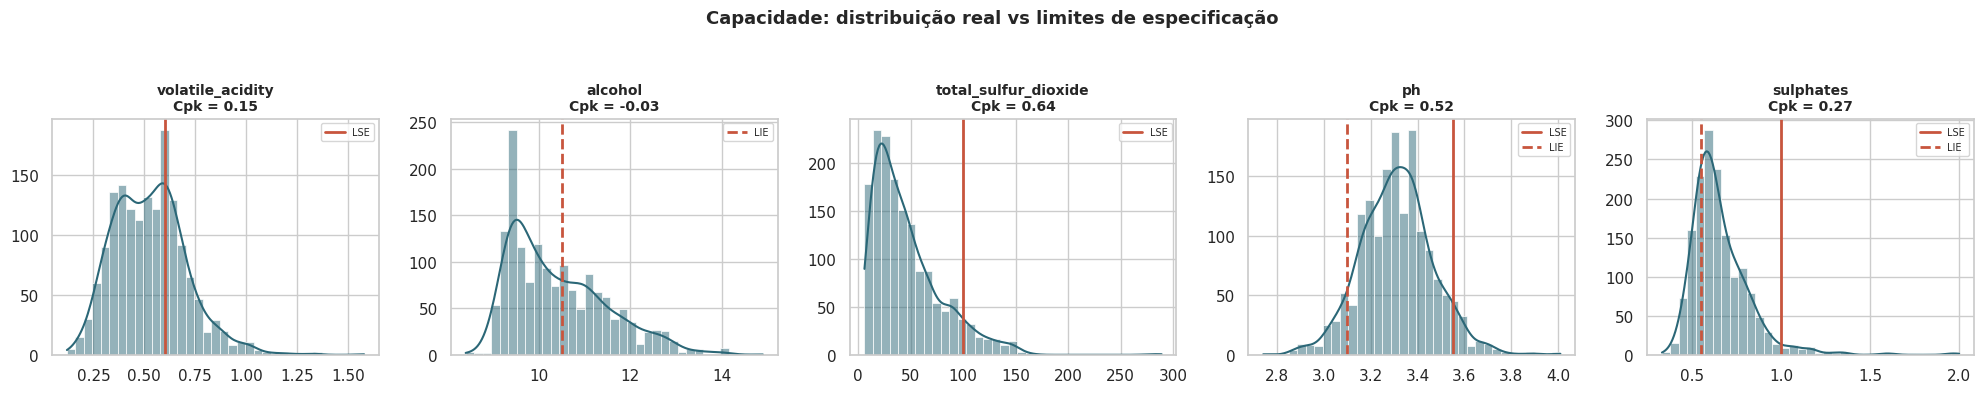

Leitura executiva: onde Cpk < 1, a especificação não é atingível com o processo atual —
ou se ajusta a centralização (média), ou se reduz variabilidade, ou se renegocia a spec.
Cpk << Pp indica processo descentralizado; Pp << Cp indica instabilidade entre lotes.


In [22]:
# ==============================================================================
# 3.5 ANÁLISE DE CAPACIDADE DO PROCESSO (Cp / Cpk / Pp / Ppk)
# ==============================================================================
# Limites de especificação definidos a partir do perfil do vinho premium (Módulo 2).
ESPECIFICACOES = {
    "volatile_acidity":     {"LIE": None, "LSE": 0.60},   # acima disso, risco de avinagramento
    "alcohol":              {"LIE": 10.5, "LSE": None},   # abaixo disso, dificilmente é premium
    "total_sulfur_dioxide": {"LIE": None, "LSE": 100.0},  # limite tecnológico/sensorial
    "ph":                   {"LIE": 3.10, "LSE": 3.55},   # janela de estabilidade microbiológica
    "sulphates":            {"LIE": 0.55, "LSE": 1.00},
}

def analise_capacidade(serie, lie, lse, tam_subgrupo=8):
    x = np.asarray(serie, dtype=float)
    n_sub = len(x) // tam_subgrupo
    m = x[:n_sub * tam_subgrupo].reshape(n_sub, tam_subgrupo)
    rbar_ = (m.max(axis=1) - m.min(axis=1)).mean()
    s_dentro = rbar_ / CONSTANTES.loc[tam_subgrupo, "d2"]   # curto prazo -> Cp/Cpk
    s_total = x.std(ddof=1)                                  # longo prazo -> Pp/Ppk
    mu = x.mean()
    def _idx(s):
        cp = (lse - lie) / (6 * s) if (lie is not None and lse is not None) else np.nan
        cpu = (lse - mu) / (3 * s) if lse is not None else np.inf
        cpl = (mu - lie) / (3 * s) if lie is not None else np.inf
        return cp, min(cpu, cpl)
    cp, cpk = _idx(s_dentro)
    pp, ppk = _idx(s_total)
    fora = 0
    if lse is not None: fora += (x > lse).sum()
    if lie is not None: fora += (x < lie).sum()
    return dict(media=mu, sigma_dentro=s_dentro, sigma_total=s_total, Cp=cp, Cpk=cpk,
                Pp=pp, Ppk=ppk, ppm_observado=fora / len(x) * 1e6)

res_cap = []
for var, esp in ESPECIFICACOES.items():
    r_ = analise_capacidade(data[var], esp["LIE"], esp["LSE"])
    r_["variavel"] = LABELS_PT[var]
    r_["LIE"], r_["LSE"] = esp["LIE"], esp["LSE"]
    res_cap.append(r_)

cap_df = pd.DataFrame(res_cap).set_index("variavel")[
    ["LIE", "LSE", "media", "sigma_dentro", "sigma_total", "Cp", "Cpk", "Pp", "Ppk", "ppm_observado"]]

def veredito(cpk):
    if np.isinf(cpk) or pd.isna(cpk): return "n/a"
    return ("INCAPAZ (ação imediata)" if cpk < 1.0 else
            "marginal (monitorar)" if cpk < 1.33 else
            "capaz" if cpk < 1.67 else "excelente")
cap_df["veredito"] = cap_df["Cpk"].apply(veredito)

print("ANÁLISE DE CAPACIDADE — Cpk < 1,00 = processo incapaz | 1,33 = mínimo aceitável | 1,67 = classe mundial")
display(cap_df.round(3))

fig, axes = plt.subplots(1, len(ESPECIFICACOES), figsize=(4.0 * len(ESPECIFICACOES), 4))
for ax, (var, esp) in zip(np.atleast_1d(axes), ESPECIFICACOES.items()):
    sns.histplot(data[var], bins=35, kde=True, ax=ax, color="#2b6777", edgecolor="white")
    if esp["LSE"] is not None: ax.axvline(esp["LSE"], color="#c8553d", lw=2, label="LSE")
    if esp["LIE"] is not None: ax.axvline(esp["LIE"], color="#c8553d", lw=2, ls="--", label="LIE")
    ax.set_title(f"{var}\nCpk = {cap_df.loc[LABELS_PT[var], 'Cpk']:.2f}", fontsize=10)
    ax.set_xlabel(""); ax.set_ylabel(""); ax.legend(fontsize=7)
fig.suptitle("Capacidade: distribuição real vs limites de especificação", fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

print("Leitura executiva: onde Cpk < 1, a especificação não é atingível com o processo atual —")
print("ou se ajusta a centralização (média), ou se reduz variabilidade, ou se renegocia a spec.")
print("Cpk << Pp indica processo descentralizado; Pp << Cp indica instabilidade entre lotes.")


In [23]:
# ==============================================================================
# 4.1 CONTROLE DE VAZAMENTO: O CUSTO DAS DUPLICATAS
# ==============================================================================
# Teste explícito: treinar com e sem duplicatas e medir a diferença de performance.
dados_dup = data.copy()
dados_dedup = data.drop_duplicates(subset=FEATURES + ["quality"]).reset_index(drop=True)
print(f"Base original: {len(dados_dup)} | Base sem duplicatas: {len(dados_dedup)} "
      f"({len(dados_dup)-len(dados_dedup)} removidas)")

def avalia_rapido(df, rotulo):
    Xa, ya = df[FEATURES], df["premium"]
    Xtr, Xte, ytr, yte = train_test_split(Xa, ya, test_size=0.2,
                                          random_state=RANDOM_STATE, stratify=ya)
    m = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                               class_weight="balanced").fit(Xtr, ytr)
    p = m.predict_proba(Xte)[:, 1]
    return {"cenario": rotulo, "n_treino": len(Xtr), "n_teste": len(Xte),
            "ROC_AUC": roc_auc_score(yte, p), "PR_AUC": average_precision_score(yte, p)}

comp_leak = pd.DataFrame([avalia_rapido(dados_dup, "Com duplicatas (otimista)"),
                          avalia_rapido(dados_dedup, "Sem duplicatas (honesto)")])
display(comp_leak.round(4))
delta = comp_leak.ROC_AUC[0] - comp_leak.ROC_AUC[1]
print(f"\n>>> Diferença de ROC-AUC: {delta:+.4f}. Toda métrica reportada daqui em diante usa a")
print("    base SEM duplicatas. Reportar o número otimista seria vender performance inexistente.")

# Base de trabalho definitiva
X = dados_dedup[FEATURES]
y = dados_dedup["premium"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
print(f"\nTreino: {X_train.shape} | Teste: {X_test.shape} | Taxa premium no treino: {y_train.mean():.3f}")


Base original: 1599 | Base sem duplicatas: 1359 (240 removidas)


,cenario,n_treino,n_teste,ROC_AUC,PR_AUC
0,Com duplicatas (otimista),1279,320,0.938,0.840
1,Sem duplicatas (honesto),1087,272,0.883,0.594



>>> Diferença de ROC-AUC: +0.0546. Toda métrica reportada daqui em diante usa a
    base SEM duplicatas. Reportar o número otimista seria vender performance inexistente.

Treino: (1087, 11) | Teste: (272, 11) | Taxa premium no treino: 0.135


BENCHMARK — validação cruzada estratificada 5-fold no conjunto de treino


,modelo,ROC_AUC,±,PR_AUC,F1,Recall,Precisão,Acur_balanceada,tempo_fit_s
0,Extra Trees,0.882,0.021,0.540,0.357,0.251,0.632,0.614,2.221
1,Random Forest,0.874,0.028,0.541,0.404,0.292,0.677,0.635,2.883
2,SVM (RBF),0.867,0.030,0.524,0.515,0.761,0.389,0.787,0.266
3,Gradient Boosting (Hist),0.866,0.029,0.502,0.475,0.462,0.492,0.694,0.450
4,Regressão Logística,0.856,0.032,0.493,0.508,0.816,0.370,0.799,0.015
5,KNN (k=15),0.840,0.026,0.444,0.331,0.251,0.494,0.604,0.008
6,Baseline (classe majoritária),0.500,0.000,0.135,0.000,0.000,0.000,0.500,0.003


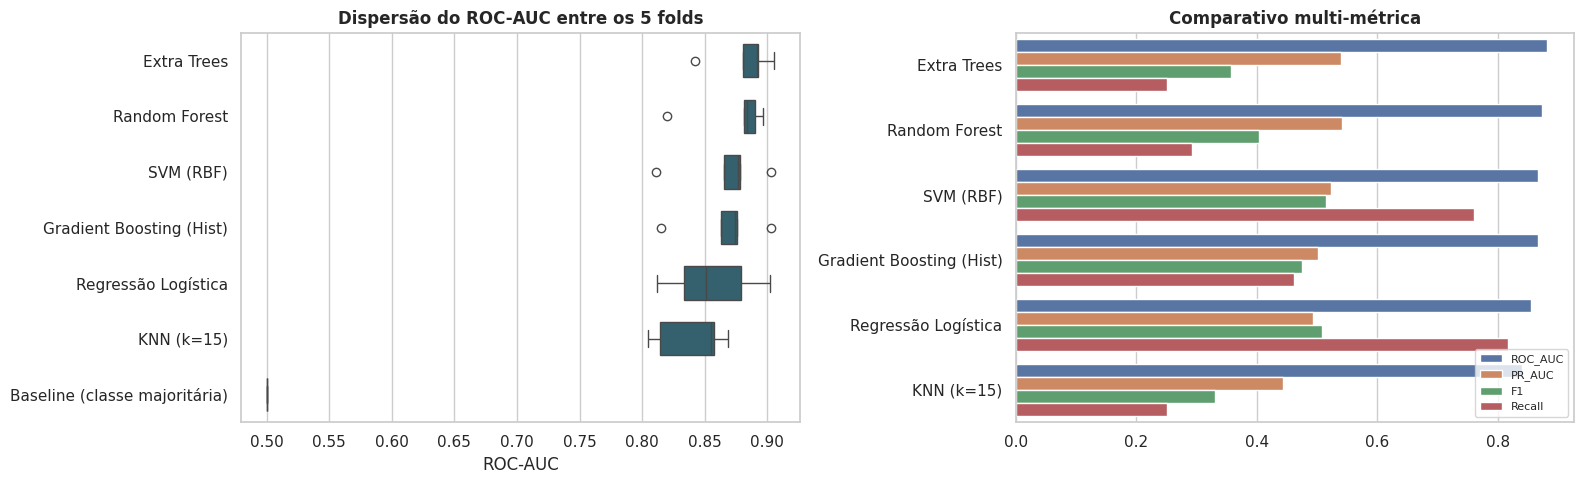

>>> Modelo vencedor por ROC-AUC: Extra Trees
Observe o gap entre F1 e ROC-AUC: com 13% de classe positiva, o F1 no threshold padrão
de 0,50 é estruturalmente baixo. O ajuste de threshold é feito no módulo prescritivo.


In [24]:
# ==============================================================================
# 4.2 BENCHMARK DE MODELOS COM VALIDAÇÃO CRUZADA ESTRATIFICADA
# ==============================================================================
MODELOS = {
    "Baseline (classe majoritária)": Pipeline([("m", DummyClassifier(strategy="most_frequent"))]),
    "Regressão Logística": Pipeline([("sc", StandardScaler()),
        ("m", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE))]),
    "KNN (k=15)": Pipeline([("sc", StandardScaler()), ("m", KNeighborsClassifier(n_neighbors=15))]),
    "SVM (RBF)": Pipeline([("sc", StandardScaler()),
        ("m", SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE))]),
    "Random Forest": Pipeline([("m", RandomForestClassifier(n_estimators=400,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
    "Extra Trees": Pipeline([("m", ExtraTreesClassifier(n_estimators=400,
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))]),
    "Gradient Boosting (Hist)": Pipeline([("m", HistGradientBoostingClassifier(
        class_weight="balanced", random_state=RANDOM_STATE))]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
metricas = ["roc_auc", "average_precision", "f1", "recall", "precision", "balanced_accuracy"]

linhas, folds_auc = [], {}
for nome, pipe in MODELOS.items():
    sc = cross_validate(pipe, X_train, y_train, cv=cv, scoring=metricas, n_jobs=-1)
    folds_auc[nome] = sc["test_roc_auc"]
    linhas.append({
        "modelo": nome,
        "ROC_AUC": sc["test_roc_auc"].mean(), "±": sc["test_roc_auc"].std(),
        "PR_AUC": sc["test_average_precision"].mean(),
        "F1": sc["test_f1"].mean(), "Recall": sc["test_recall"].mean(),
        "Precisão": sc["test_precision"].mean(),
        "Acur_balanceada": sc["test_balanced_accuracy"].mean(),
        "tempo_fit_s": sc["fit_time"].mean(),
    })

bench = pd.DataFrame(linhas).sort_values("ROC_AUC", ascending=False).reset_index(drop=True)
print("BENCHMARK — validação cruzada estratificada 5-fold no conjunto de treino")
display(bench.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ordem = bench.modelo.tolist()
sns.boxplot(data=pd.DataFrame(folds_auc)[ordem], orient="h", ax=axes[0],
            hue=None, color="#2b6777", width=0.6)
axes[0].set_title("Dispersão do ROC-AUC entre os 5 folds")
axes[0].set_xlabel("ROC-AUC")

b2 = bench[bench.modelo != "Baseline (classe majoritária)"].melt(
    id_vars="modelo", value_vars=["ROC_AUC", "PR_AUC", "F1", "Recall"],
    var_name="metrica", value_name="valor")
sns.barplot(data=b2, x="valor", y="modelo", hue="metrica", ax=axes[1])
axes[1].set_title("Comparativo multi-métrica"); axes[1].set_xlabel(""); axes[1].set_ylabel("")
axes[1].legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

melhor_nome = bench.loc[0, "modelo"]
print(f">>> Modelo vencedor por ROC-AUC: {melhor_nome}")
print("Observe o gap entre F1 e ROC-AUC: com 13% de classe positiva, o F1 no threshold padrão")
print("de 0,50 é estruturalmente baixo. O ajuste de threshold é feito no módulo prescritivo.")



In [25]:
# ==============================================================================
# 4.3 OTIMIZAÇÃO DE HIPERPARÂMETROS (BUSCA ALEATÓRIA)
# ==============================================================================
GRIDS = {
    "Random Forest": {
        "m__n_estimators": [200, 400, 600, 800],
        "m__max_depth": [None, 8, 12, 16, 24],
        "m__min_samples_split": [2, 4, 8, 12],
        "m__min_samples_leaf": [1, 2, 4],
        "m__max_features": ["sqrt", "log2", 0.4, 0.6],
    },
    "Extra Trees": {
        "m__n_estimators": [200, 400, 600, 800],
        "m__max_depth": [None, 10, 16, 24],
        "m__min_samples_split": [2, 4, 8],
        "m__min_samples_leaf": [1, 2, 4],
        "m__max_features": ["sqrt", "log2", 0.5],
    },
    "Gradient Boosting (Hist)": {
        "m__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "m__max_iter": [200, 400, 600],
        "m__max_leaf_nodes": [15, 31, 63],
        "m__min_samples_leaf": [5, 10, 20, 40],
        "m__l2_regularization": [0.0, 0.5, 1.0, 3.0],
    },
    "SVM (RBF)": {"m__C": [0.5, 1, 3, 10, 30], "m__gamma": ["scale", 0.05, 0.1, 0.3]},
    "Regressão Logística": {"m__C": [0.01, 0.1, 1, 10], "m__penalty": ["l2"]},
    "KNN (k=15)": {"m__n_neighbors": [5, 9, 15, 25, 41], "m__weights": ["uniform", "distance"]},
}

busca = RandomizedSearchCV(
    estimator=MODELOS[melhor_nome], param_distributions=GRIDS[melhor_nome],
    n_iter=40, cv=cv, scoring="roc_auc", n_jobs=-1, random_state=RANDOM_STATE, verbose=0)
busca.fit(X_train, y_train)

print(f"Melhor ROC-AUC em CV: {busca.best_score_:.4f}")
print("Melhores hiperparâmetros:")
for k, v in busca.best_params_.items():
    print(f"   {k.replace('m__','')}: {v}")

modelo_final = busca.best_estimator_

top_cfg = (pd.DataFrame(busca.cv_results_)
           .sort_values("rank_test_score")
           .head(8)[["mean_test_score", "std_test_score", "params"]])
print("\nTop 8 configurações testadas:")
display(top_cfg.round(4))


Melhor ROC-AUC em CV: 0.8856
Melhores hiperparâmetros:
   n_estimators: 200
   min_samples_split: 4
   min_samples_leaf: 2
   max_features: 0.5
   max_depth: 16

Top 8 configurações testadas:


,mean_test_score,std_test_score,params
32,0.886,0.018,"{'m__n_estimators': 200, 'm__min_samples_split..."
14,0.885,0.021,"{'m__n_estimators': 800, 'm__min_samples_split..."
6,0.883,0.020,"{'m__n_estimators': 600, 'm__min_samples_split..."
31,0.883,0.025,"{'m__n_estimators': 800, 'm__min_samples_split..."
1,0.882,0.025,"{'m__n_estimators': 800, 'm__min_samples_split..."
29,0.882,0.023,"{'m__n_estimators': 600, 'm__min_samples_split..."
38,0.882,0.023,"{'m__n_estimators': 600, 'm__min_samples_split..."
21,0.882,0.021,"{'m__n_estimators': 400, 'm__min_samples_split..."


RELATÓRIO DE CLASSIFICAÇÃO (threshold padrão = 0,50)
              precision    recall  f1-score   support

       Comum      0.917     0.936     0.926       235
     Premium      0.531     0.459     0.493        37

    accuracy                          0.871       272
   macro avg      0.724     0.698     0.710       272
weighted avg      0.864     0.871     0.867       272

ROC-AUC ....... 0.8815
PR-AUC ........ 0.6237  (linha de base = 0.136)
Brier score ... 0.0861  (0 = calibração perfeita)


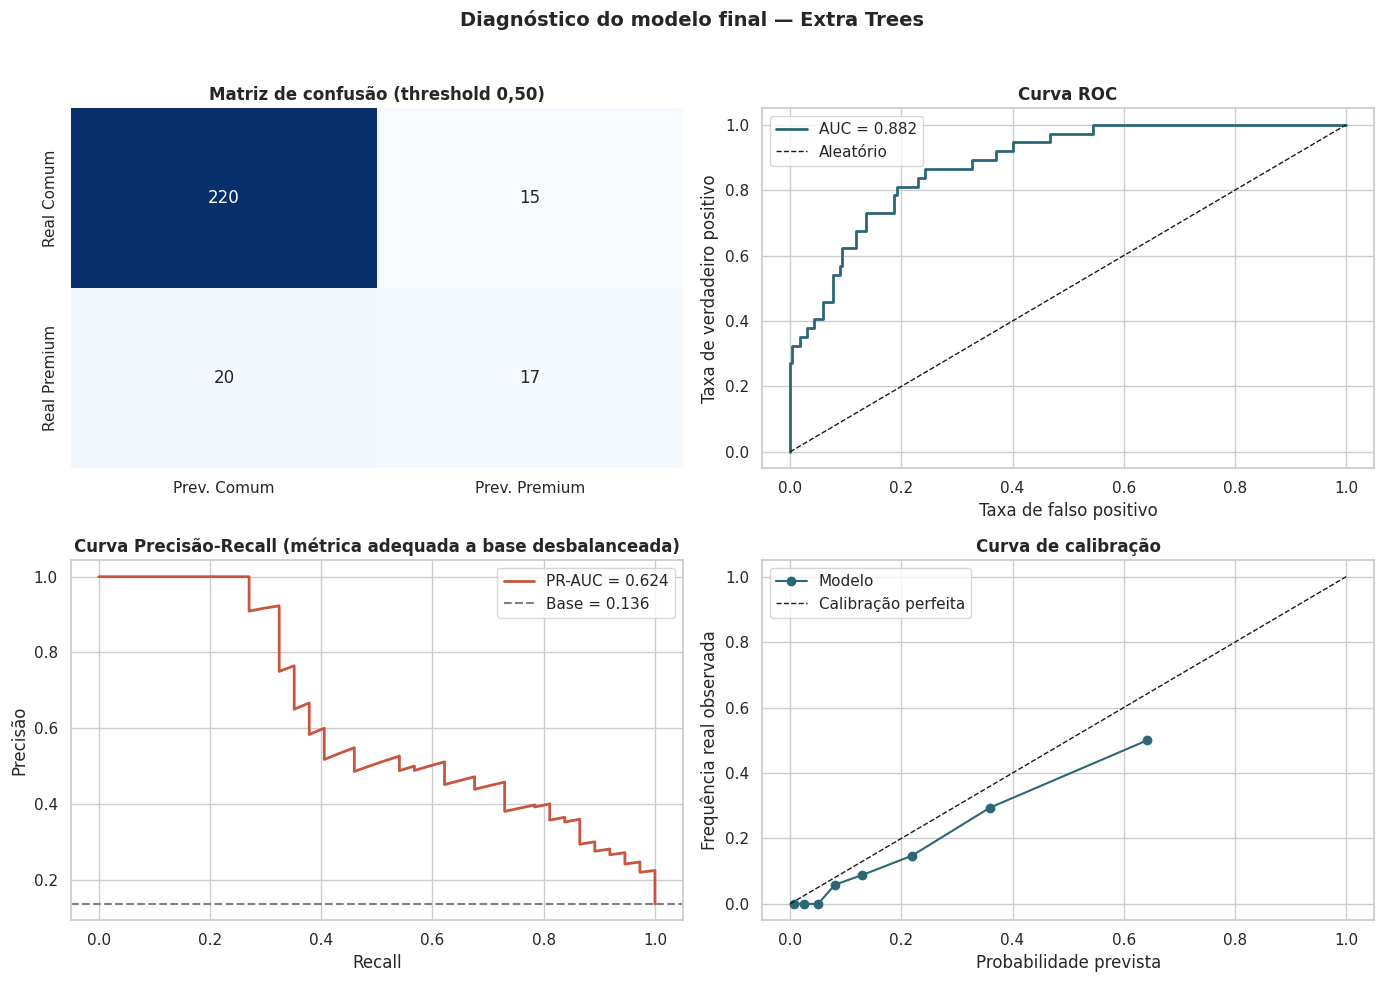

Falsos positivos: 15 (vinho comum enviado à linha premium)
Falsos negativos: 20 (vinho premium desperdiçado na linha comum)
A calibração importa: no módulo prescritivo as probabilidades viram decisão financeira.


In [26]:
# ==============================================================================
# 4.4 AVALIAÇÃO NO CONJUNTO DE TESTE (dados nunca vistos)
# ==============================================================================
proba_test = modelo_final.predict_proba(X_test)[:, 1]
pred_05 = (proba_test >= 0.5).astype(int)

print("RELATÓRIO DE CLASSIFICAÇÃO (threshold padrão = 0,50)")
print(classification_report(y_test, pred_05, target_names=["Comum", "Premium"], digits=3))
print(f"ROC-AUC ....... {roc_auc_score(y_test, proba_test):.4f}")
print(f"PR-AUC ........ {average_precision_score(y_test, proba_test):.4f}  (linha de base = {y_test.mean():.3f})")
print(f"Brier score ... {brier_score_loss(y_test, proba_test):.4f}  (0 = calibração perfeita)")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cm = confusion_matrix(y_test, pred_05)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[0, 0],
            xticklabels=["Prev. Comum", "Prev. Premium"], yticklabels=["Real Comum", "Real Premium"])
axes[0, 0].set_title("Matriz de confusão (threshold 0,50)")

fpr, tpr, _ = roc_curve(y_test, proba_test)
axes[0, 1].plot(fpr, tpr, lw=2, color="#2b6777",
                label=f"AUC = {roc_auc_score(y_test, proba_test):.3f}")
axes[0, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Aleatório")
axes[0, 1].set_xlabel("Taxa de falso positivo"); axes[0, 1].set_ylabel("Taxa de verdadeiro positivo")
axes[0, 1].set_title("Curva ROC"); axes[0, 1].legend()

prec, rec, _ = precision_recall_curve(y_test, proba_test)
axes[1, 0].plot(rec, prec, lw=2, color="#c8553d",
                label=f"PR-AUC = {average_precision_score(y_test, proba_test):.3f}")
axes[1, 0].axhline(y_test.mean(), ls="--", color="grey", label=f"Base = {y_test.mean():.3f}")
axes[1, 0].set_xlabel("Recall"); axes[1, 0].set_ylabel("Precisão")
axes[1, 0].set_title("Curva Precisão-Recall (métrica adequada a base desbalanceada)")
axes[1, 0].legend()

fr_pos, med_prev = calibration_curve(y_test, proba_test, n_bins=8, strategy="quantile")
axes[1, 1].plot(med_prev, fr_pos, "o-", color="#2b6777", label="Modelo")
axes[1, 1].plot([0, 1], [0, 1], "k--", lw=1, label="Calibração perfeita")
axes[1, 1].set_xlabel("Probabilidade prevista"); axes[1, 1].set_ylabel("Frequência real observada")
axes[1, 1].set_title("Curva de calibração"); axes[1, 1].legend()

fig.suptitle(f"Diagnóstico do modelo final — {melhor_nome}", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96]); plt.show()

vn, fp, fn, vp = cm.ravel()
print(f"Falsos positivos: {fp} (vinho comum enviado à linha premium)")
print(f"Falsos negativos: {fn} (vinho premium desperdiçado na linha comum)")
print("A calibração importa: no módulo prescritivo as probabilidades viram decisão financeira.")


ROC-AUC treino: 1.0000 | teste: 0.8815 | gap: 0.1185
Gap alto em ensembles de árvore é esperado (memorização do treino); o que importa é a
estabilidade entre CV e teste, não a diferença treino-teste isolada.


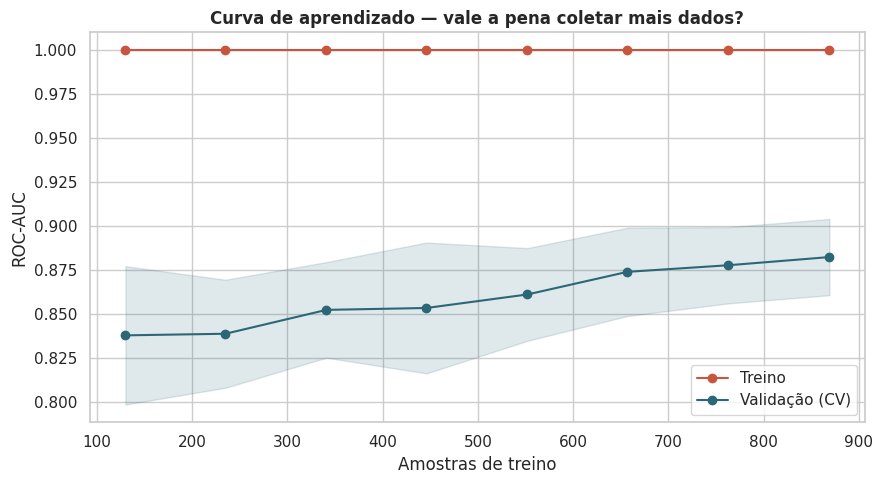

Inclinação da curva de validação no trecho final: +0.00396 ROC-AUC por 100 amostras.
VEREDITO: a curva ainda sobe. Coletar mais amostras do mesmo tipo AINDA gera retorno —
dobrar a base tende a render ganho mensurável de AUC. Investimento em coleta se justifica.


In [27]:
# ==============================================================================
# 4.5 DIAGNÓSTICO DE OVERFITTING E CURVA DE APRENDIZADO
# ==============================================================================
score_treino = roc_auc_score(y_train, modelo_final.predict_proba(X_train)[:, 1])
score_teste = roc_auc_score(y_test, proba_test)
print(f"ROC-AUC treino: {score_treino:.4f} | teste: {score_teste:.4f} | gap: {score_treino-score_teste:.4f}")
print("Gap alto em ensembles de árvore é esperado (memorização do treino); o que importa é a")
print("estabilidade entre CV e teste, não a diferença treino-teste isolada.")

tam, sc_tr, sc_val = learning_curve(
    modelo_final, X_train, y_train, cv=cv, scoring="roc_auc",
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=-1, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tam, sc_tr.mean(1), "o-", color="#c8553d", label="Treino")
ax.fill_between(tam, sc_tr.mean(1) - sc_tr.std(1), sc_tr.mean(1) + sc_tr.std(1), alpha=0.15, color="#c8553d")
ax.plot(tam, sc_val.mean(1), "o-", color="#2b6777", label="Validação (CV)")
ax.fill_between(tam, sc_val.mean(1) - sc_val.std(1), sc_val.mean(1) + sc_val.std(1), alpha=0.15, color="#2b6777")
ax.set_xlabel("Amostras de treino"); ax.set_ylabel("ROC-AUC")
ax.set_title("Curva de aprendizado — vale a pena coletar mais dados?")
ax.legend(); plt.tight_layout(); plt.show()

incl = (sc_val.mean(1)[-1] - sc_val.mean(1)[-3]) / (tam[-1] - tam[-3]) * 100
print(f"Inclinação da curva de validação no trecho final: {incl:+.5f} ROC-AUC por 100 amostras.")
if incl > 0.002:
    print("VEREDITO: a curva ainda sobe. Coletar mais amostras do mesmo tipo AINDA gera retorno —")
    print("dobrar a base tende a render ganho mensurável de AUC. Investimento em coleta se justifica.")
else:
    print("VEREDITO: a curva está achatada. Mais amostras do mesmo tipo NÃO melhoram o modelo —")
    print("o ganho viria de novas variáveis (safra, terroir, tempo de barrica), não de mais linhas.")



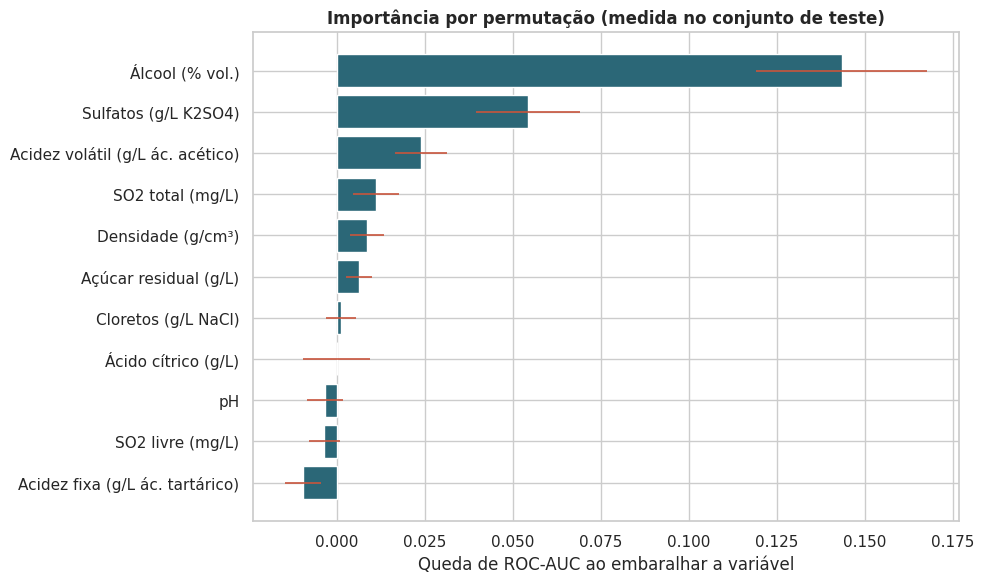

,variavel,queda_media_auc,desvio
0,Álcool (% vol.),0.143,0.024
1,Sulfatos (g/L K2SO4),0.054,0.015
2,Acidez volátil (g/L ác. acético),0.024,0.007
3,SO2 total (mg/L),0.011,0.007
4,Densidade (g/cm³),0.009,0.005
5,Açúcar residual (g/L),0.006,0.004
6,Cloretos (g/L NaCl),0.001,0.004
7,Ácido cítrico (g/L),-0.000,0.010
8,pH,-0.004,0.005
9,SO2 livre (mg/L),-0.004,0.004


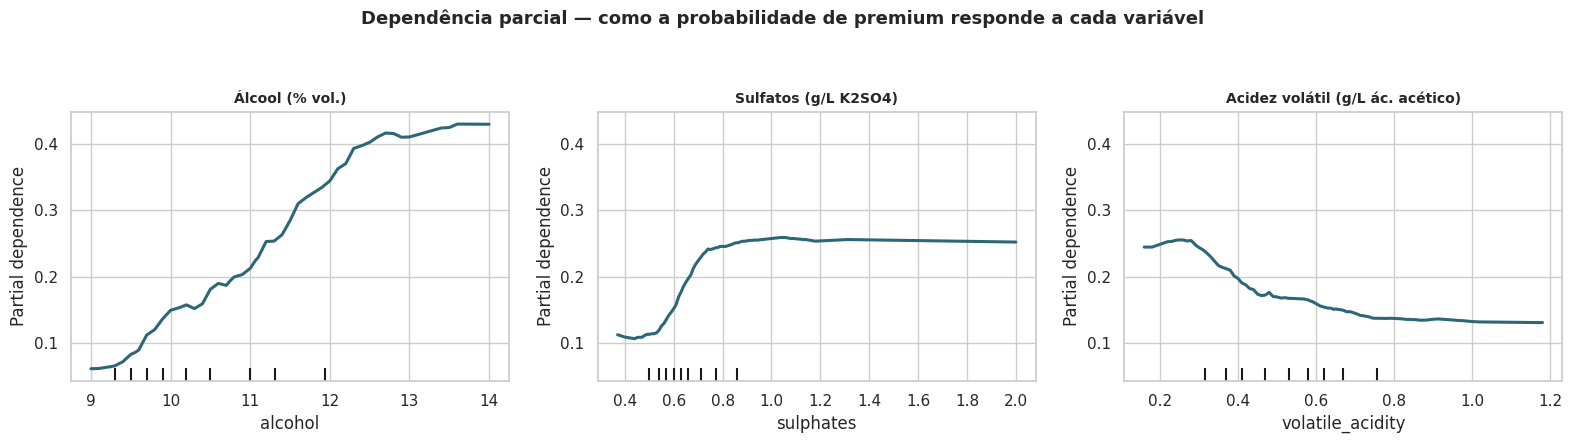

Estas curvas são a ponte para a análise prescritiva: elas mostram ONDE mexer e a partir
de que ponto o retorno marginal do ajuste começa a saturar.


In [28]:
# ==============================================================================
# 4.6 IMPORTÂNCIA DAS VARIÁVEIS (PERMUTAÇÃO) E EFEITOS PARCIAIS
# ==============================================================================
perm = permutation_importance(modelo_final, X_test, y_test, n_repeats=25,
                              random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
imp_df = (pd.DataFrame({"variavel": [LABELS_PT.get(c, c) for c in FEATURES],
                        "queda_media_auc": perm.importances_mean,
                        "desvio": perm.importances_std})
          .sort_values("queda_media_auc", ascending=False).reset_index(drop=True))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(imp_df.variavel, imp_df.queda_media_auc, xerr=imp_df.desvio,
        color="#2b6777", error_kw={"ecolor": "#c8553d", "lw": 1.2})
ax.invert_yaxis()
ax.set_xlabel("Queda de ROC-AUC ao embaralhar a variável")
ax.set_title("Importância por permutação (medida no conjunto de teste)")
plt.tight_layout(); plt.show()
display(imp_df.round(4))

top3 = [FEATURES[i] for i in np.argsort(perm.importances_mean)[::-1][:3]]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
PartialDependenceDisplay.from_estimator(modelo_final, X_test, top3, ax=ax,
                                        line_kw={"color": "#2b6777", "lw": 2.2})
for a, t in zip(ax, top3):
    a.set_title(LABELS_PT.get(t, t), fontsize=10)
fig.suptitle("Dependência parcial — como a probabilidade de premium responde a cada variável",
             fontsize=13, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.92]); plt.show()

print("Estas curvas são a ponte para a análise prescritiva: elas mostram ONDE mexer e a partir")
print("de que ponto o retorno marginal do ajuste começa a saturar.")


PERFIL MÉDIO POR TIPO DE RESULTADO


alcohol       volatile_acidity       sulphates        prob      
                  mean count             mean count      mean count  mean count
tipo                                                                           
Acerto comum    10.176   220            0.566   220     0.643   220 0.114   220
Acerto premium  12.229    17            0.412    17     0.780    17 0.706    17
Falso negativo  11.120    20            0.420    20     0.732    20 0.279    20
Falso positivo  11.813    15            0.351    15     0.733    15 0.593    15

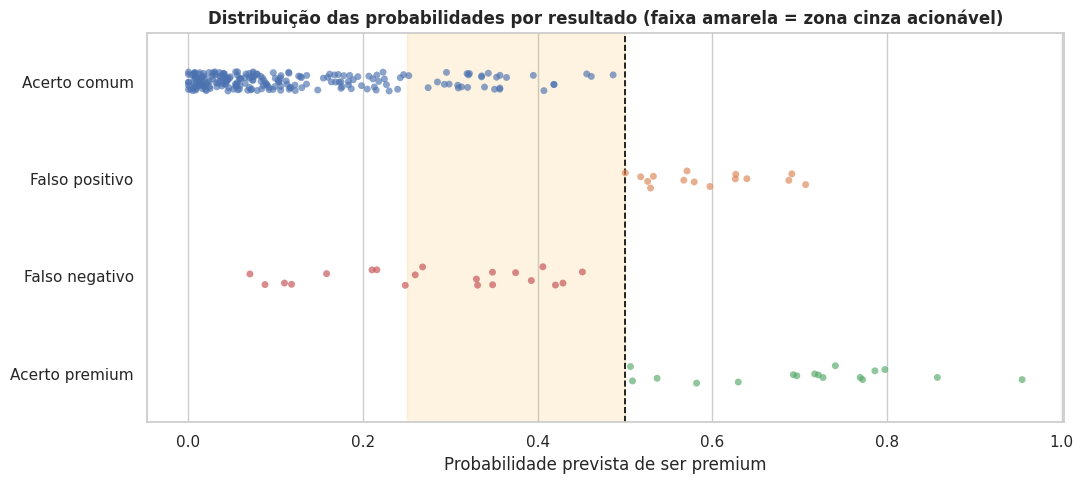

Os falsos negativos concentrados na zona cinza são o alvo prioritário: são vinhos a poucos
ajustes de virar premium. Isso é explorado nos contrafactuais do Módulo 5.


In [29]:
# ==============================================================================
# 4.7 ANÁLISE DE ERROS
# ==============================================================================
erros = X_test.copy()
erros["real"] = y_test.values
erros["prob"] = proba_test
erros["prev"] = pred_05
erros["tipo"] = np.select(
    [(erros.real == 1) & (erros.prev == 1), (erros.real == 0) & (erros.prev == 0),
     (erros.real == 0) & (erros.prev == 1), (erros.real == 1) & (erros.prev == 0)],
    ["Acerto premium", "Acerto comum", "Falso positivo", "Falso negativo"], default="-")

resumo_erro = erros.groupby("tipo")[["alcohol", "volatile_acidity", "sulphates", "prob"]].agg(["mean", "count"])
print("PERFIL MÉDIO POR TIPO DE RESULTADO")
display(resumo_erro.round(3))

fig, ax = plt.subplots(figsize=(11, 5))
sns.stripplot(data=erros, x="prob", y="tipo", hue="tipo", ax=ax, alpha=0.65, size=5, legend=False,
              order=["Acerto comum", "Falso positivo", "Falso negativo", "Acerto premium"])
ax.axvline(0.5, color="black", ls="--", lw=1.2)
ax.axvspan(0.25, 0.5, color="#f2b134", alpha=0.15)
ax.set_xlabel("Probabilidade prevista de ser premium"); ax.set_ylabel("")
ax.set_title("Distribuição das probabilidades por resultado (faixa amarela = zona cinza acionável)")
plt.tight_layout(); plt.show()

print("Os falsos negativos concentrados na zona cinza são o alvo prioritário: são vinhos a poucos")
print("ajustes de virar premium. Isso é explorado nos contrafactuais do Módulo 5.")


MATRIZ DE MARGEM POR GARRAFA (R$)


,R$/garrafa
VP,40.000
FN,15.000
VN,15.000
FP,-5.000


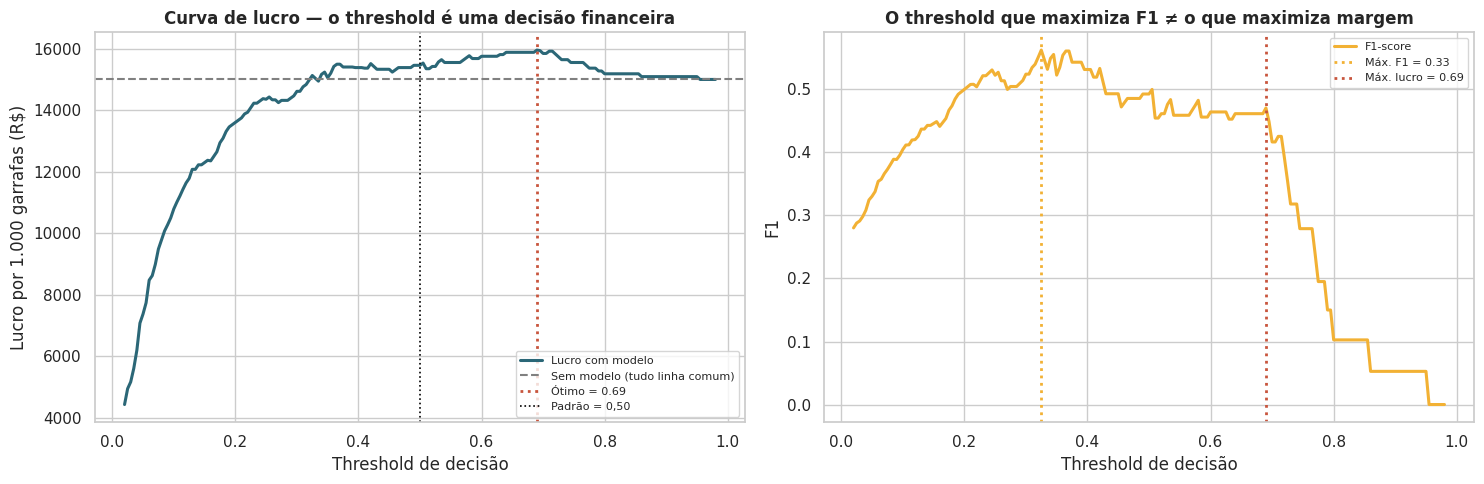

Threshold ótimo (lucro): 0.690   |   Threshold ótimo (F1): 0.325
Lucro/1.000 garrafas -> sem modelo: R$ 15,000 | threshold 0,50: R$ 15,460 | threshold ótimo: R$ 15,956

>>> Ganho incremental do modelo no ponto ótimo: R$ 956 por 1.000 garrafas (6.4%).
>>> Só a calibração do threshold (de 0,50 para 0.69) vale R$ 496 por 1.000 garrafas — sem tocar no modelo.

Relatório no ponto de operação ótimo:
              precision    recall  f1-score   support

       Comum      0.903     0.991     0.945       235
     Premium      0.857     0.324     0.471        37

    accuracy                          0.901       272
   macro avg      0.880     0.658     0.708       272
weighted avg      0.897     0.901     0.881       272

ANÁLISE DE SENSIBILIDADE DO PONTO DE OPERAÇÃO


,custo_reclamacao_R$,threshold_otimo,lucro_por_mil_R$
0,15,0.020,"25,386.029"
1,30,0.245,"16,911.765"
2,45,0.690,"15,955.882"
3,60,0.710,"15,919.118"
4,90,0.710,"15,919.118"


Leitura: quanto maior o custo do falso positivo, mais conservador (alto) o threshold.
Esta tabela é o que se leva para a mesa de decisão — não a matriz de confusão.


In [30]:
# ==============================================================================
# 5.1 PONTO DE OPERAÇÃO ÓTIMO — OTIMIZAÇÃO POR LUCRO, NÃO POR ACURÁCIA
# ==============================================================================
# Premissas econômicas (por garrafa) — ajuste conforme a realidade do cliente.
PRECO_PREMIUM = 60.0
PRECO_COMUM = 35.0
CUSTO_PRODUCAO = 20.0
CUSTO_RECLAMACAO = 45.0   # devolução + retrabalho + dano de marca ao vender ruim como premium

MARGEM = {
    "VP": PRECO_PREMIUM - CUSTO_PRODUCAO,                       # acerto premium
    "FN": PRECO_COMUM - CUSTO_PRODUCAO,                          # premium vendido como comum
    "VN": PRECO_COMUM - CUSTO_PRODUCAO,                          # acerto comum
    "FP": PRECO_PREMIUM - CUSTO_PRODUCAO - CUSTO_RECLAMACAO,     # comum vendido como premium
}
print("MATRIZ DE MARGEM POR GARRAFA (R$)")
display(pd.DataFrame([MARGEM], index=["margem"]).T.rename(columns={"margem": "R$/garrafa"}))

def lucro_por_threshold(y_true, proba, t):
    pred = (proba >= t).astype(int)
    vn, fp, fn, vp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return (vp * MARGEM["VP"] + fn * MARGEM["FN"] + vn * MARGEM["VN"] + fp * MARGEM["FP"])

ths = np.linspace(0.02, 0.98, 193)
lucros = np.array([lucro_por_threshold(y_test, proba_test, t) for t in ths])
lucro_por_mil = lucros / len(y_test) * 1000
f1s = np.array([f1_score(y_test, (proba_test >= t).astype(int), zero_division=0) for t in ths])

t_lucro = ths[lucro_por_mil.argmax()]
t_f1 = ths[f1s.argmax()]
# Cenário de referência: sem modelo, tudo vai para a linha comum
lucro_sem_modelo = (MARGEM["VN"]) * 1000

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(ths, lucro_por_mil, lw=2.2, color="#2b6777", label="Lucro com modelo")
axes[0].axhline(lucro_sem_modelo, ls="--", color="grey", label="Sem modelo (tudo linha comum)")
axes[0].axvline(t_lucro, color="#c8553d", ls=":", lw=2, label=f"Ótimo = {t_lucro:.2f}")
axes[0].axvline(0.5, color="black", ls=":", lw=1.2, label="Padrão = 0,50")
axes[0].set_xlabel("Threshold de decisão"); axes[0].set_ylabel("Lucro por 1.000 garrafas (R$)")
axes[0].set_title("Curva de lucro — o threshold é uma decisão financeira")
axes[0].legend(fontsize=8)

axes[1].plot(ths, f1s, lw=2.2, color="#f2b134", label="F1-score")
axes[1].axvline(t_f1, color="#f2b134", ls=":", lw=2, label=f"Máx. F1 = {t_f1:.2f}")
axes[1].axvline(t_lucro, color="#c8553d", ls=":", lw=2, label=f"Máx. lucro = {t_lucro:.2f}")
axes[1].set_xlabel("Threshold de decisão"); axes[1].set_ylabel("F1")
axes[1].set_title("O threshold que maximiza F1 ≠ o que maximiza margem")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

ganho = lucro_por_mil.max() - lucro_sem_modelo
ganho_05 = lucro_por_threshold(y_test, proba_test, 0.5) / len(y_test) * 1000 - lucro_sem_modelo
print(f"Threshold ótimo (lucro): {t_lucro:.3f}   |   Threshold ótimo (F1): {t_f1:.3f}")
print(f"Lucro/1.000 garrafas -> sem modelo: R$ {lucro_sem_modelo:,.0f} | "
      f"threshold 0,50: R$ {lucro_sem_modelo+ganho_05:,.0f} | threshold ótimo: R$ {lucro_por_mil.max():,.0f}")
print(f"\n>>> Ganho incremental do modelo no ponto ótimo: R$ {ganho:,.0f} por 1.000 garrafas "
      f"({ganho/lucro_sem_modelo*100:.1f}%).")
print(f">>> Só a calibração do threshold (de 0,50 para {t_lucro:.2f}) vale R$ {ganho-ganho_05:,.0f} "
      "por 1.000 garrafas — sem tocar no modelo.")

pred_otimo = (proba_test >= t_lucro).astype(int)
print("\nRelatório no ponto de operação ótimo:")
print(classification_report(y_test, pred_otimo, target_names=["Comum", "Premium"], digits=3))

# Sensibilidade: o ótimo muda com o custo de reclamação?
sens = []
for custo in [15, 30, 45, 60, 90]:
    m = {"VP": PRECO_PREMIUM - CUSTO_PRODUCAO, "FN": PRECO_COMUM - CUSTO_PRODUCAO,
         "VN": PRECO_COMUM - CUSTO_PRODUCAO, "FP": PRECO_PREMIUM - CUSTO_PRODUCAO - custo}
    def _l(t):
        vn, fp, fn, vp = confusion_matrix(y_test, (proba_test >= t).astype(int), labels=[0, 1]).ravel()
        return (vp * m["VP"] + fn * m["FN"] + vn * m["VN"] + fp * m["FP"]) / len(y_test) * 1000
    vals = np.array([_l(t) for t in ths])
    sens.append({"custo_reclamacao_R$": custo, "threshold_otimo": ths[vals.argmax()],
                 "lucro_por_mil_R$": vals.max()})
print("ANÁLISE DE SENSIBILIDADE DO PONTO DE OPERAÇÃO")
display(pd.DataFrame(sens).round(3))
print("Leitura: quanto maior o custo do falso positivo, mais conservador (alto) o threshold.")
print("Esta tabela é o que se leva para a mesa de decisão — não a matriz de confusão.")


SIMULAÇÃO WHAT-IF — impacto de cada ajuste sobre toda a produção


,acao,prob_media_depois,taxa_premium_depois_%,ganho_pp,ganho_R$_por_mil
0,"Elevar sulfatos em 0,20 g/L",0.250,6.250,1.100,275.740
1,"Elevar sulfatos em 0,10 g/L",0.220,5.880,0.740,183.820
2,"Elevar o teor alcoólico em 0,5% vol.",0.240,5.510,0.370,91.910
3,"Elevar o teor alcoólico em 1,0% vol.",0.280,5.510,0.370,91.910
4,Reduzir SO2 total em 15 mg/L,0.200,5.150,0.000,0.000
5,"Reduzir a acidez volátil em 0,20 g/L",0.220,4.410,-0.740,-183.820
6,"Reduzir a acidez volátil em 0,10 g/L",0.210,4.410,-0.740,-183.820
7,"Reduzir cloretos em 0,02 g/L",0.190,4.040,-1.100,-275.740
8,"Elevar ácido cítrico em 0,10 g/L",0.200,3.680,-1.470,-367.650


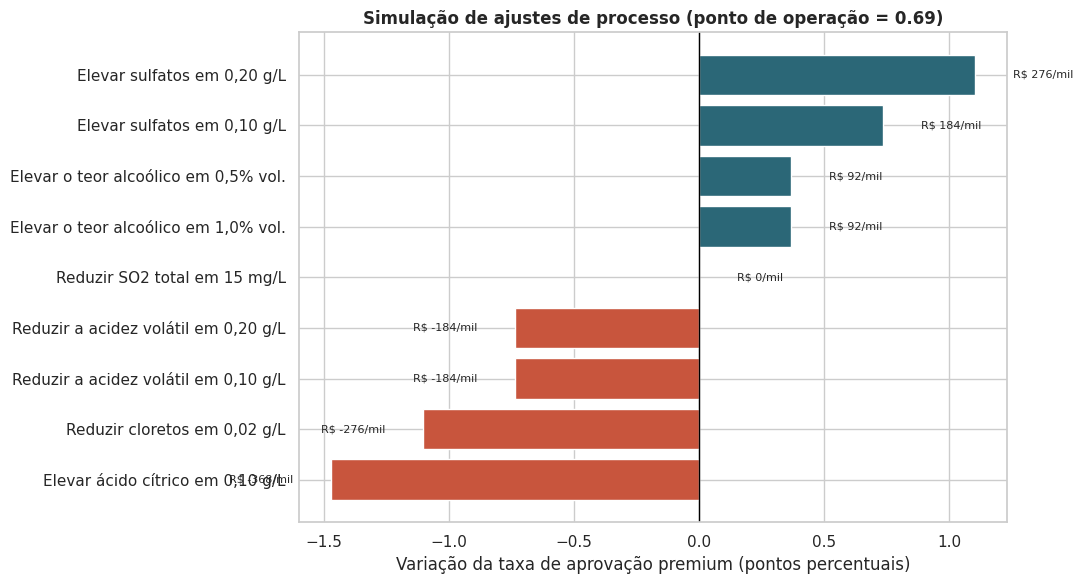

Ressalva metodológica obrigatória: o modelo captura ASSOCIAÇÃO, não causalidade.
A simulação indica prioridade de teste, não garantia de efeito. O próximo passo correto
é um experimento controlado (lote-piloto A/B) nas 2 alavancas de maior ganho simulado.


In [31]:

# ==============================================================================
# 5.2 SIMULAÇÃO WHAT-IF: IMPACTO DE AJUSTES DE PROCESSO
# ==============================================================================
# Usamos o modelo como simulador: aplicamos um ajuste em toda a produção e medimos
# a variação da taxa esperada de aprovação premium.
AJUSTES = [
    ("alcohol", +0.5, "Elevar o teor alcoólico em 0,5% vol."),
    ("alcohol", +1.0, "Elevar o teor alcoólico em 1,0% vol."),
    ("volatile_acidity", -0.10, "Reduzir a acidez volátil em 0,10 g/L"),
    ("volatile_acidity", -0.20, "Reduzir a acidez volátil em 0,20 g/L"),
    ("sulphates", +0.10, "Elevar sulfatos em 0,10 g/L"),
    ("sulphates", +0.20, "Elevar sulfatos em 0,20 g/L"),
    ("citric_acid", +0.10, "Elevar ácido cítrico em 0,10 g/L"),
    ("total_sulfur_dioxide", -15.0, "Reduzir SO2 total em 15 mg/L"),
    ("chlorides", -0.02, "Reduzir cloretos em 0,02 g/L"),
]

base_prob = modelo_final.predict_proba(X_test)[:, 1]
base_taxa = (base_prob >= t_lucro).mean()

sim = []
for var, delta, desc in AJUSTES:
    Xm = X_test.copy()
    Xm[var] = Xm[var] + delta
    p = modelo_final.predict_proba(Xm)[:, 1]
    taxa = (p >= t_lucro).mean()
    sim.append({"acao": desc, "variavel": var, "delta": delta,
                "prob_media_antes": base_prob.mean(), "prob_media_depois": p.mean(),
                "taxa_premium_antes_%": base_taxa * 100, "taxa_premium_depois_%": taxa * 100,
                "ganho_pp": (taxa - base_taxa) * 100,
                "ganho_R$_por_mil": (taxa - base_taxa) * 1000 * (MARGEM["VP"] - MARGEM["FN"])})

sim_df = pd.DataFrame(sim).sort_values("ganho_pp", ascending=False).reset_index(drop=True)
print("SIMULAÇÃO WHAT-IF — impacto de cada ajuste sobre toda a produção")
display(sim_df[["acao", "prob_media_depois", "taxa_premium_depois_%", "ganho_pp", "ganho_R$_por_mil"]].round(2))

fig, ax = plt.subplots(figsize=(11, 6))
cores = ["#2b6777" if v > 0 else "#c8553d" for v in sim_df.ganho_pp]
ax.barh(sim_df.acao, sim_df.ganho_pp, color=cores)
ax.axvline(0, color="black", lw=1)
ax.invert_yaxis()
ax.set_xlabel("Variação da taxa de aprovação premium (pontos percentuais)")
ax.set_title(f"Simulação de ajustes de processo (ponto de operação = {t_lucro:.2f})")
for i, (v, r) in enumerate(zip(sim_df["ganho_pp"], sim_df["ganho_R$_por_mil"])):
    ax.text(v + (0.15 if v >= 0 else -0.15), i, f"R$ {r:,.0f}/mil", va="center",
            ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout(); plt.show()

print("Ressalva metodológica obrigatória: o modelo captura ASSOCIAÇÃO, não causalidade.")
print("A simulação indica prioridade de teste, não garantia de efeito. O próximo passo correto")
print("é um experimento controlado (lote-piloto A/B) nas 2 alavancas de maior ganho simulado.")



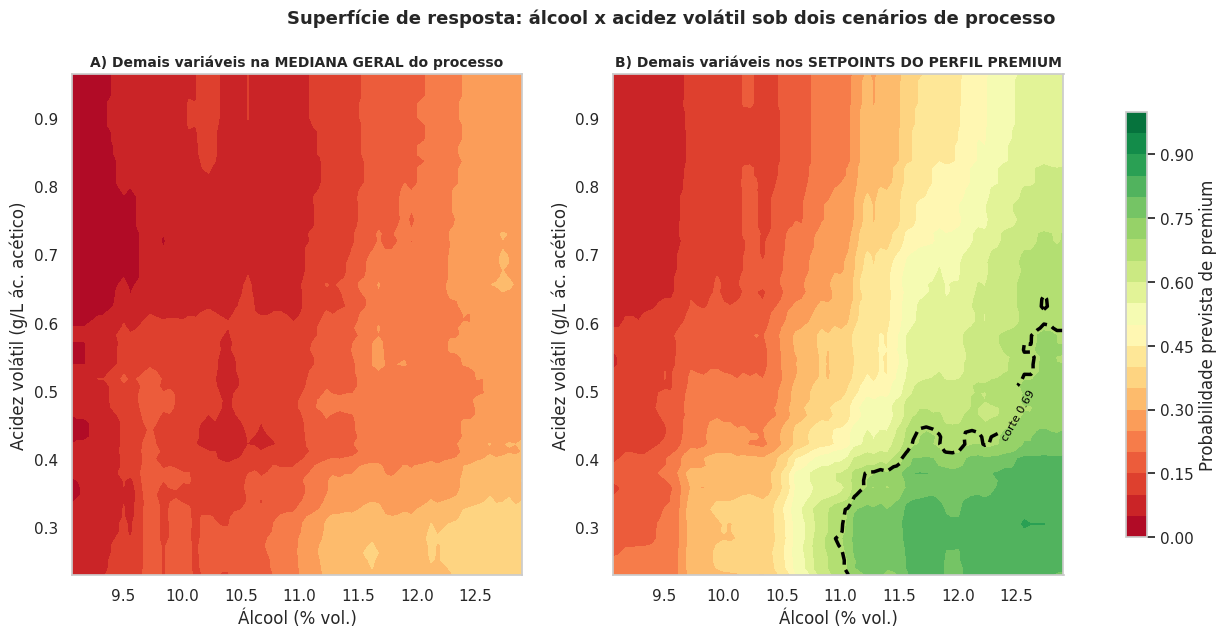


A) Demais variáveis na MEDIANA GERAL do processo
   Probabilidade máxima alcançável: 0.395
   Nenhuma combinação atinge o corte de 0.69 neste cenário.

B) Demais variáveis nos SETPOINTS DO PERFIL PREMIUM
   Probabilidade máxima alcançável: 0.856
   JANELA OPERACIONAL (p >= 0.69):
      Álcool (% vol.): a partir de 11.01
      Acidez volátil (g/L ác. acético): até 0.635
      Cobertura: 14.5% do espaço operacional viável

>>> INSIGHT PRESCRITIVO CENTRAL: se o cenário A não atinge o corte e o B atinge, a
    conclusão é que NÃO EXISTE alavanca isolada. Álcool e acidez volátil só entregam
    resultado premium quando o RESTANTE do perfil (sulfatos, cloretos, SO2, densidade)
    também está no setpoint correto. Isso muda a estratégia: o plano de ação precisa ser
    de perfil completo, não de ajuste pontual de uma variável.


In [32]:
# ==============================================================================
# 5.3 MAPA DE RESPOSTA 2D — ZONA OPERACIONAL ALVO
# ==============================================================================
v1, v2 = "alcohol", "volatile_acidity"
g1 = np.linspace(X[v1].quantile(0.02), X[v1].quantile(0.98), 70)
g2 = np.linspace(X[v2].quantile(0.02), X[v2].quantile(0.98), 70)
G1, G2 = np.meshgrid(g1, g2)

premium_obs = dados_dedup[dados_dedup.premium == 1]
CENARIOS = {
    "A) Demais variáveis na MEDIANA GERAL do processo": X_train.median(),
    "B) Demais variáveis nos SETPOINTS DO PERFIL PREMIUM": premium_obs[FEATURES].median(),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))
janelas = {}
for ax, (titulo, base) in zip(axes, CENARIOS.items()):
    grade = pd.concat([base.to_frame().T] * G1.size, ignore_index=True)
    grade[v1] = G1.ravel()
    grade[v2] = G2.ravel()
    Z = modelo_final.predict_proba(grade[FEATURES])[:, 1].reshape(G1.shape)
    cf_ = ax.contourf(G1, G2, Z, levels=np.linspace(0, 1, 21), cmap="RdYlGn", vmin=0, vmax=1)
    if Z.max() >= t_lucro:
        cs = ax.contour(G1, G2, Z, levels=[t_lucro], colors="black", linewidths=2.5, linestyles="--")
        ax.clabel(cs, fmt={t_lucro: f"corte {t_lucro:.2f}"}, fontsize=8)
    ax.set_xlabel(LABELS_PT[v1]); ax.set_ylabel(LABELS_PT[v2])
    ax.set_title(titulo, fontsize=10)
    janelas[titulo] = Z
plt.colorbar(cf_, ax=axes, label="Probabilidade prevista de premium", shrink=0.85)
fig.suptitle("Superfície de resposta: álcool x acidez volátil sob dois cenários de processo",
             fontsize=13, fontweight="bold")
plt.show()

for titulo, Z in janelas.items():
    m_alvo = Z >= t_lucro
    print(f"\n{titulo}")
    print(f"   Probabilidade máxima alcançável: {Z.max():.3f}")
    if m_alvo.any():
        print(f"   JANELA OPERACIONAL (p >= {t_lucro:.2f}):")
        print(f"      {LABELS_PT[v1]}: a partir de {G1[m_alvo].min():.2f}")
        print(f"      {LABELS_PT[v2]}: até {G2[m_alvo].max():.3f}")
        print(f"      Cobertura: {m_alvo.mean()*100:.1f}% do espaço operacional viável")
    else:
        print(f"   Nenhuma combinação atinge o corte de {t_lucro:.2f} neste cenário.")

print("\n>>> INSIGHT PRESCRITIVO CENTRAL: se o cenário A não atinge o corte e o B atinge, a")
print("    conclusão é que NÃO EXISTE alavanca isolada. Álcool e acidez volátil só entregam")
print("    resultado premium quando o RESTANTE do perfil (sulfatos, cloretos, SO2, densidade)")
print("    também está no setpoint correto. Isso muda a estratégia: o plano de ação precisa ser")
print("    de perfil completo, não de ajuste pontual de uma variável.")



Vinhos na zona cinza selecionados para simulação de resgate: 35


,id,prob_inicial,prob_final,convertido,custo_R$,real_premium,Δ_alcohol,Δ_sulphates,Δ_volatile_acidity,Δ_citric_acid
0,292,0.687,0.726,True,0.450,0,0.000,0.050,0.000,0.000
4,424,0.626,0.698,True,0.450,0,0.000,0.050,0.000,0.000
19,326,0.461,0.477,False,0.700,0,0.000,0.000,0.000,0.050
21,803,0.451,0.752,True,0.900,1,0.000,0.100,0.000,0.000
1,1193,0.639,0.690,True,1.150,0,0.000,0.050,0.000,0.050
3,1122,0.627,0.701,True,1.350,0,0.000,0.150,0.000,0.000
11,1039,0.532,0.596,False,1.650,0,0.100,0.050,0.000,0.000
5,127,0.597,0.679,False,2.050,0,0.000,0.150,0.000,0.050
2,1201,0.629,0.706,True,2.350,1,0.100,0.050,0.000,0.050
33,432,0.356,0.464,False,2.600,0,0.100,0.000,0.000,0.100



Taxa de conversão simulada: 60.0% dos lotes da zona cinza
Custo médio de intervenção nos convertidos: R$ 4.86/garrafa
Ganho de margem por conversão: R$ 25.00/garrafa
>>> ROI da intervenção: 414% (lucro líquido de R$ 20.14 por garrafa resgatada)


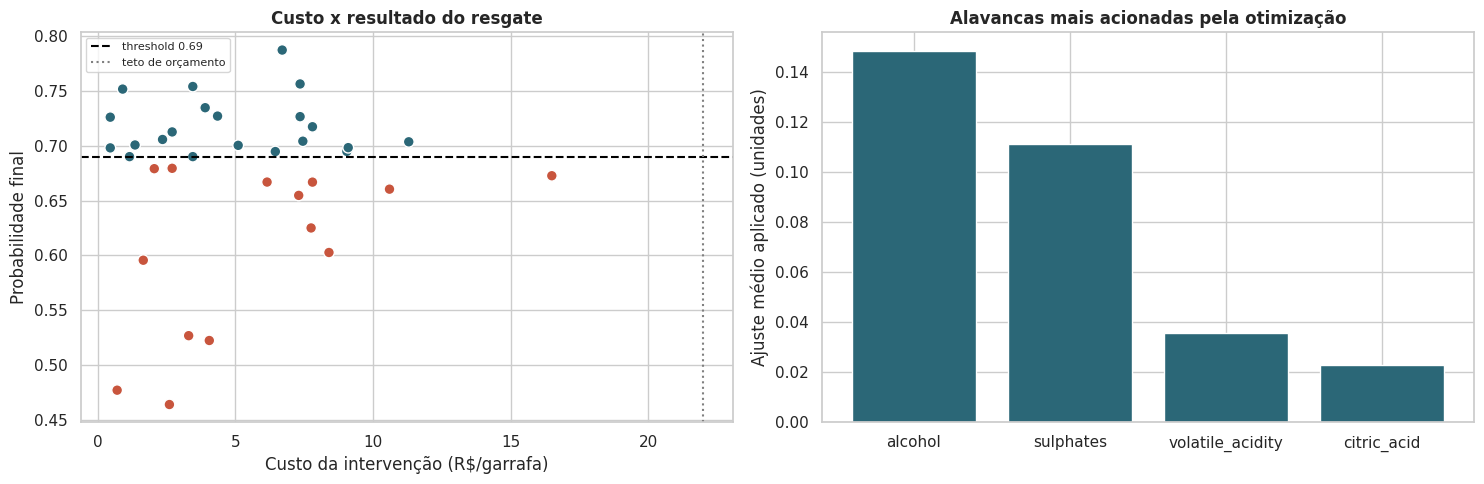


Este é o artefato prescritivo de maior valor: uma lista priorizada de lotes, com a
intervenção exata, o custo e o retorno esperado de cada um.


In [33]:
# ==============================================================================
# 5.4 CONTRAFACTUAIS: QUAIS LOTES VALE A PENA RESGATAR E A QUE CUSTO
# ==============================================================================
# Para cada vinho na "zona cinza", busca gulosa pelo conjunto de ajustes de menor custo
# que eleva a probabilidade acima do ponto de operação.
ALAVANCAS = {
    # variavel: (passo, custo_R$_por_passo_por_garrafa, limite_total_de_ajuste)
    "alcohol":          (+0.10, 1.20, +1.50),
    "sulphates":        (+0.05, 0.45, +0.35),
    "volatile_acidity": (-0.05, 3.00, -0.25),
    "citric_acid":      (+0.05, 0.70, +0.25),
}
ORCAMENTO_MAX = 22.0   # teto: ganho de margem ao converter comum->premium é R$ 25/garrafa

def resgatar(linha, modelo, threshold, max_iter=60):
    atual = linha.copy()
    usado = {v: 0.0 for v in ALAVANCAS}
    custo = 0.0
    p = modelo.predict_proba(atual.to_frame().T[FEATURES])[:, 1][0]
    p0 = p
    for _ in range(max_iter):
        if p >= threshold or custo >= ORCAMENTO_MAX:
            break
        melhor = None
        for var, (passo, c_passo, limite) in ALAVANCAS.items():
            if abs(usado[var] + passo) > abs(limite):
                continue
            cand = atual.copy()
            cand[var] = cand[var] + passo
            p_novo = modelo.predict_proba(cand.to_frame().T[FEATURES])[:, 1][0]
            eficiencia = (p_novo - p) / c_passo
            if melhor is None or eficiencia > melhor[0]:
                melhor = (eficiencia, var, passo, c_passo, p_novo, cand)
        if melhor is None or melhor[0] <= 0:
            break
        _, var, passo, c_passo, p, atual = melhor
        usado[var] += passo
        custo += c_passo
    return p0, p, custo, usado

zona_cinza = erros[(erros.prob >= 0.15) & (erros.prob < t_lucro)].nlargest(35, "prob")
print(f"Vinhos na zona cinza selecionados para simulação de resgate: {len(zona_cinza)}")

resultados = []
for idx, linha in zona_cinza[FEATURES].iterrows():
    p0, p1, custo, usado = resgatar(linha, modelo_final, t_lucro)
    resultados.append({
        "id": idx, "prob_inicial": p0, "prob_final": p1, "convertido": p1 >= t_lucro,
        "custo_R$": custo, "real_premium": int(erros.loc[idx, "real"]),
        **{f"Δ_{v}": round(usado[v], 3) for v in ALAVANCAS},
    })

cf_df = pd.DataFrame(resultados).sort_values("custo_R$")
display(cf_df.round(3).head(20))

taxa_conv = cf_df.convertido.mean()
custo_medio = cf_df.loc[cf_df.convertido, "custo_R$"].mean() if cf_df.convertido.any() else np.nan
ganho_unit = MARGEM["VP"] - MARGEM["FN"]
print(f"\nTaxa de conversão simulada: {taxa_conv*100:.1f}% dos lotes da zona cinza")
print(f"Custo médio de intervenção nos convertidos: R$ {custo_medio:.2f}/garrafa")
print(f"Ganho de margem por conversão: R$ {ganho_unit:.2f}/garrafa")
if not np.isnan(custo_medio):
    print(f">>> ROI da intervenção: {(ganho_unit-custo_medio)/custo_medio*100:.0f}% "
          f"(lucro líquido de R$ {ganho_unit-custo_medio:.2f} por garrafa resgatada)")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].scatter(cf_df["custo_R$"], cf_df["prob_final"],
                c=np.where(cf_df.convertido, "#2b6777", "#c8553d"), s=60, edgecolors="white")
axes[0].axhline(t_lucro, ls="--", color="black", label=f"threshold {t_lucro:.2f}")
axes[0].axvline(ORCAMENTO_MAX, ls=":", color="grey", label="teto de orçamento")
axes[0].set_xlabel("Custo da intervenção (R$/garrafa)"); axes[0].set_ylabel("Probabilidade final")
axes[0].set_title("Custo x resultado do resgate"); axes[0].legend(fontsize=8)

uso = cf_df[[f"Δ_{v}" for v in ALAVANCAS]].abs().mean()
axes[1].bar([c.replace("Δ_", "") for c in uso.index], uso.values, color="#2b6777")
axes[1].set_ylabel("Ajuste médio aplicado (unidades)")
axes[1].set_title("Alavancas mais acionadas pela otimização")
plt.tight_layout(); plt.show()

print("\nEste é o artefato prescritivo de maior valor: uma lista priorizada de lotes, com a")
print("intervenção exata, o custo e o retorno esperado de cada um.")


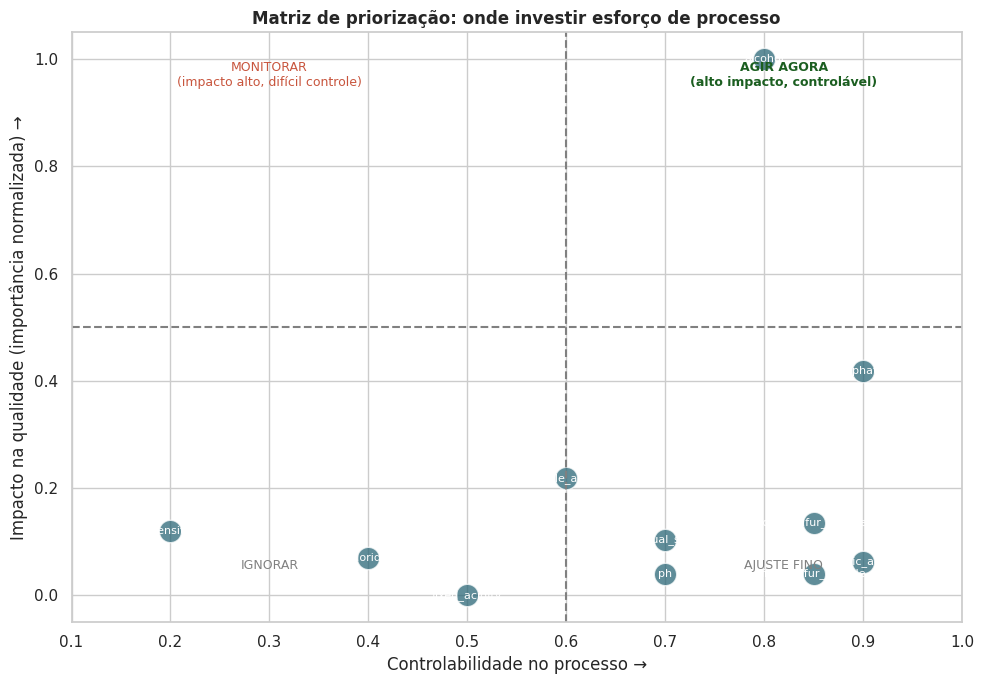

SETPOINTS RECOMENDADOS (derivados do perfil real dos vinhos premium)


,alvo_mediana,faixa_min_(p25),faixa_max_(p75),media_atual_geral,gap_para_o_alvo,controlabilidade,impacto_norm,prioridade
Álcool (% vol.),11.600,10.800,12.300,10.432,1.168,0.800,1.000,0.800
Sulfatos (g/L K2SO4),0.740,0.658,0.820,0.659,0.081,0.900,0.418,0.376
Acidez volátil (g/L ác. acético),0.370,0.310,0.482,0.529,-0.159,0.600,0.219,0.131
SO2 total (mg/L),26.500,17.000,42.250,46.826,-20.326,0.850,0.135,0.115
Açúcar residual (g/L),2.300,1.900,2.800,2.523,-0.223,0.700,0.104,0.073
Ácido cítrico (g/L),0.400,0.300,0.490,0.272,0.128,0.900,0.063,0.057
SO2 livre (mg/L),11.000,6.000,17.000,15.893,-4.893,0.850,0.040,0.034
pH,3.270,3.200,3.370,3.310,-0.040,0.700,0.040,0.028
Cloretos (g/L NaCl),0.072,0.062,0.085,0.088,-0.017,0.400,0.070,0.028
Densidade (g/cm³),0.996,0.995,0.997,0.997,-0.001,0.200,0.119,0.024


In [34]:
# ==============================================================================
# 5.5 SETPOINTS RECOMENDADOS E MATRIZ IMPACTO x CONTROLABILIDADE
# ==============================================================================
CONTROLABILIDADE = {   # 0 a 1: quão facilmente a enologia controla a variável no processo
    "alcohol": 0.8, "volatile_acidity": 0.6, "sulphates": 0.9, "citric_acid": 0.9,
    "total_sulfur_dioxide": 0.85, "free_sulfur_dioxide": 0.85, "chlorides": 0.4,
    "residual_sugar": 0.7, "ph": 0.7, "density": 0.2, "fixed_acidity": 0.5,
}
impacto = dict(zip(FEATURES, perm.importances_mean))
imp_norm = {k: (v - min(impacto.values())) / (max(impacto.values()) - min(impacto.values()))
            for k, v in impacto.items()}

fig, ax = plt.subplots(figsize=(10, 7))
for var in FEATURES:
    x_, y_ = CONTROLABILIDADE[var], imp_norm[var]
    ax.scatter(x_, y_, s=260, color="#2b6777", alpha=0.75, edgecolors="white")
    ax.annotate(var, (x_, y_), fontsize=8, ha="center", va="center", color="white")
ax.axvline(0.6, color="grey", ls="--"); ax.axhline(0.5, color="grey", ls="--")
ax.text(0.82, 0.95, "AGIR AGORA\n(alto impacto, controlável)", ha="center", fontsize=9,
        color="#1b5e20", fontweight="bold")
ax.text(0.30, 0.95, "MONITORAR\n(impacto alto, difícil controle)", ha="center", fontsize=9, color="#c8553d")
ax.text(0.82, 0.05, "AJUSTE FINO", ha="center", fontsize=9, color="grey")
ax.text(0.30, 0.05, "IGNORAR", ha="center", fontsize=9, color="grey")
ax.set_xlabel("Controlabilidade no processo →"); ax.set_ylabel("Impacto na qualidade (importância normalizada) →")
ax.set_xlim(0.1, 1.0); ax.set_ylim(-0.05, 1.05)
ax.set_title("Matriz de priorização: onde investir esforço de processo")
plt.tight_layout(); plt.show()

# Setpoints derivados do perfil dos vinhos premium de fato observados
setpoints = pd.DataFrame({
    "alvo_mediana": premium_obs[FEATURES].median(),
    "faixa_min_(p25)": premium_obs[FEATURES].quantile(0.25),
    "faixa_max_(p75)": premium_obs[FEATURES].quantile(0.75),
    "media_atual_geral": dados_dedup[FEATURES].mean(),
})
setpoints["gap_para_o_alvo"] = setpoints["alvo_mediana"] - setpoints["media_atual_geral"]
setpoints["controlabilidade"] = pd.Series(CONTROLABILIDADE)
setpoints["impacto_norm"] = pd.Series(imp_norm)
setpoints["prioridade"] = (setpoints["impacto_norm"] * setpoints["controlabilidade"]).round(3)
setpoints.index = [LABELS_PT.get(i, i) for i in setpoints.index]
print("SETPOINTS RECOMENDADOS (derivados do perfil real dos vinhos premium)")
display(setpoints.sort_values("prioridade", ascending=False).round(3))


In [36]:
# ==============================================================================
# PAINEL FINAL DE INDICADORES
# ==============================================================================
kpis = pd.DataFrame([
    ["Amostras analisadas (sem duplicatas)", f"{len(dados_dedup):,}"],
    ["Taxa de vinhos premium", f"{y.mean()*100:.1f}%"],
    ["Modelo selecionado", melhor_nome],
    ["ROC-AUC (teste)", f"{roc_auc_score(y_test, proba_test):.3f}"],
    ["PR-AUC (teste)", f"{average_precision_score(y_test, proba_test):.3f}"],
    ["Threshold ótimo por margem", f"{t_lucro:.2f}"],
    ["Ganho vs. sem modelo (por 1.000 garrafas)", f"R$ {ganho:,.0f}"],
    ["Ganho só pela calibração do threshold", f"R$ {ganho-ganho_05:,.0f}"],
    ["Variável de maior impacto", imp_df.loc[0, 'variavel']],
    ["Lotes fora de controle (carta p)", f"{len(fora_p)} de {n_lotes_p}"],
    ["Variáveis com Cpk < 1,0 (processo incapaz)", f"{int((cap_df['Cpk'] < 1).sum())} de {len(cap_df)}"],
    ["ROI da intervenção nos lotes da zona cinza", f"{(ganho_unit-custo_medio)/custo_medio*100:.0f}%" if not np.isnan(custo_medio) else "n/a"],
], columns=["Indicador", "Valor"])
display(kpis.style.hide(axis="index").set_properties(**{"text-align": "left"}))
print("\nMVP concluído: descritiva -> diagnóstica -> CEP -> preditiva -> prescritiva.")



Indicador,Valor
Amostras analisadas (sem duplicatas),"1,359"
Taxa de vinhos premium,13.5%
Modelo selecionado,Extra Trees
ROC-AUC (teste),0.882
PR-AUC (teste),0.624
Threshold ótimo por margem,0.69
Ganho vs. sem modelo (por 1.000 garrafas),R$ 956
Ganho só pela calibração do threshold,R$ 496
Variável de maior impacto,Álcool (% vol.)
Lotes fora de controle (carta p),5 de 63



MVP concluído: descritiva -> diagnóstica -> CEP -> preditiva -> prescritiva.
